# 3C Summary — One-shot QC + Plots

This notebook is designed to be **run top-to-bottom** and then shared.

It will:
1) explain the expected input format
2) load all `*_summary.csv` in the 3C folder
3) show quick tables + QC plots (counts + CIS/TRANS composition)
4) (optionally) save plots to `Outputs/3C`

## Data location
This notebook reads from `WILSONTEW_3C_FOLDER` if set; otherwise it falls back to `./ThreeC_Data`.
Current recommended 3C folder (from your setup):
- `C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary`

## Biological context for this assay

This notebook analyzes a dual-DSB yeast system designed to study **NHEJ-driven chromosomal rearrangement** and DSB co-localization dynamics after fixation.

### Important interpretation note
In this workflow, events often labeled as "trans" are **not automatically equivalent to finalized mutagenic translocations**. Here, many of these readouts represent **new DSB-locus associations captured at the fixation timepoint**, i.e., loci that ligated in close spatial proximity after crosslinking and ligation.

So the main biological interpretation is about **DSB interaction frequency and partner choice over time**, with rearrangement propensity inferred from those association patterns.

### What the current results are showing
- Cis-like/cognate outcomes still dominate many groups, as expected for NHEJ.
- Non-cognate association frequencies are recurrent across many DSB-pair contexts and replicates.
- The relative stability of these non-cognate associations across batch/locus contexts supports a model where post-damage nuclear behavior (movement/co-localization) can weaken strict dependence on pre-damage spatial proximity.

These patterns are consistent with the Aim 3 hypothesis that coordinated movement of simultaneous DSBs alters which loci encounter each other during repair-competent windows.

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
})


## Expected columns (typical)
Most 3C summary CSVs include columns like:
- `batch`, `time_point`, `DSB`, `allele`, `combo`, `cis_trans`, `repeat`, `replicate`, `count`

This notebook filters to time points 0 and 120 by default (matches the existing 3C QC report).

In [2]:
# ---- Locate 3C folder ----
threec_folder <- Sys.getenv('WILSONTEW_3C_FOLDER', unset = file.path(getwd(), 'ThreeC_Data'))
threec_folder <- normalizePath(threec_folder, winslash = '/', mustWork = FALSE)
dir.create(threec_folder, recursive = TRUE, showWarnings = FALSE)
message('Using threec_folder: ', threec_folder)

files <- list.files(threec_folder, pattern = '_summary\\.csv$', full.names = TRUE)
if (length(files) == 0) {
  stop(paste0(
    'No *_summary.csv files found in threec_folder: ', threec_folder,
    '\n\nFix: set WILSONTEW_3C_FOLDER to the directory that contains your 3C summary CSVs.'
  ))
}
message('Found ', length(files), ' file(s).')
head(files, 10)

Using threec_folder: C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary

Found 8 file(s).



[1] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_2_3C_T0_final_summary.csv"  
[2] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_2_3C_T120_final_summary.csv"
[3] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_T0_3C_summary.csv"          
[4] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_T120_3C_summary.csv"        
[5] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch6_T0_3C_summary.csv"          
[6] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch6_T120_3C_summary.csv"        
[7] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch8_T0_3C_summary.csv"          
[8] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch8_T120_3C_summary.csv"

In [3]:
# ---- Read and combine ----
# Some 3C summary CSVs include extra columns whose types vary across runs (e.g., *_loci).
# To keep binding robust, read everything as character, then parse only the columns we need.
read_one <- function(f) {
  dat <- readr::read_csv(
    f,
    show_col_types = FALSE,
    col_types = readr::cols(.default = readr::col_character())
  )
  if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
  if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
  
  # Parse key columns if present
  if ("count" %in% names(dat)) dat$count <- readr::parse_double(dat$count)
  if ("time_point" %in% names(dat)) dat$time_point <- readr::parse_number(dat$time_point)
  if ("replicate" %in% names(dat)) dat$replicate <- as.character(dat$replicate)
  
  dat <- dplyr::mutate(
    dat,
    source_path = f,
    source_dir = dirname(f),
    allele = as.character(.data[["allele"]]),
    combo = as.character(.data[["combo"]]),
    cis_trans = as.character(.data[["cis_trans"]]),
    DSB = as.character(.data[["DSB"]]),
    `repeat` = as.character(.data[["repeat"]]),
    replicate = as.character(.data[["replicate"]]),
    batch = as.character(.data[["batch"]])
  )
  dat
}

dat_raw <- purrr::map_dfr(files, read_one)
dat_raw <- dplyr::mutate(dat_raw, batch = factor(batch, levels = sort(unique(batch))))

# Match the 3C report convention: only 0 and 120 (edit if needed)
dat_raw <- dat_raw %>% filter(time_point %in% c(0, 120))

dplyr::glimpse(dat_raw)

Rows: 596
Columns: 13
$ batch          <fct> 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4…
$ DSB2_loci      <chr> "7", "7", "7", "7", "7", "7", "7", "7", "7", "7", "7", …
$ time_point     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ replicate      <chr> "2", "2", "2", "2", "2", "2", "2", "2", "2", "2", "2", …
$ alignment_name <chr> "CIS_A_to_B_DSB1_Chr12_L01", "CIS_A_to_B_DSB1_Chr12_L05…
$ cis_trans      <chr> "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS",…
$ DSB            <chr> "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1",…
$ combo          <chr> "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to…
$ allele         <chr> "Chr12_L01", "Chr12_L05", "Chr12_L07", "Chr12_L12", "Ch…
$ count          <dbl> 17041, 37724, 14131, 17156, 24218, 72, 17820, 20767, 26…
$ `repeat`       <chr> "ALL", "ALL", "ALL", "ALL", "ALL", "ALL", "ALL", "ALL",…
$ source_path    <chr> "C:/Users/dunnmk/University of Michigan Dropbox/MED-WIL…
$ source_dir     <

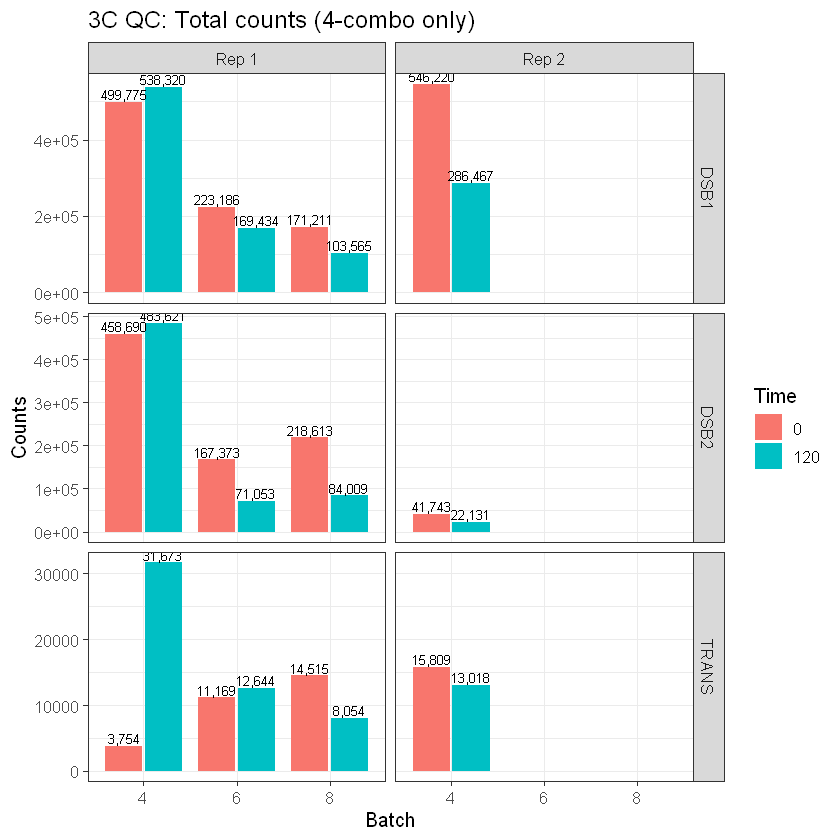

In [4]:
# ---- QC plots ----
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

dat4 <- dat_raw %>%
  filter(combo %in% combos_4) %>%
  mutate(
    replicate = if_else(is.na(replicate) | replicate == '', 'ALL', as.character(replicate)),
    replicate = if_else(str_starts(replicate, 'Rep '), replicate, paste0('Rep ', replicate))
  )

qc_totals <- dat4 %>%
  group_by(batch, time_point, DSB, replicate) %>%
  summarise(Total_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  mutate(label_counts = scales::label_number(accuracy = 1, big.mark = ',')(Total_Counts))

p_total <- ggplot(qc_totals, aes(x = batch, y = Total_Counts, fill = factor(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  geom_text(
    aes(label = label_counts),
    position = position_dodge(width = 0.85),
    vjust = -0.25,
    size = 2.8
  ) +
  facet_grid(DSB ~ replicate, scales = 'free_y') +
  theme_bw(base_size = 12) +
  labs(title = '3C QC: Total counts (4-combo only)', x = 'Batch', y = 'Counts', fill = 'Time')
print(p_total)

# Line QC plot removed per request (it was not informative).
# Keep object defined so downstream export logic remains safe.
p_cistrans <- NULL

**Figure 3. QC total counts (4-combo subset) across DSB class and replicate.**

- **Methods/Computation:** Raw counts were restricted to `A_to_B`, `C_to_D`, `A_to_D`, and `C_to_B`, then summarized by batch, time point, DSB class, and replicate. The plotted quantity is $N_{b,t,d,r}=\sum_i c_i$ for each batch $b$, time $t$, DSB class $d$, and replicate $r$.
- **Biological relevance (with sources):** These totals define effective sampling depth per stratum and therefore the confidence of downstream composition/fold-change estimates; uneven depth can inflate variance in inferred DSB partner-choice behavior in NHEJ-focused analyses [1,3].

In [ ]:
# ---- Optional: save plots for sharing ----
out_dir <- file.path(getwd(), 'Outputs', '3C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(filename = file.path(out_dir, '3C_QC_total_counts.png'), plot = p_total, width = 14, height = 7, dpi = 200)
if (!is.null(p_cistrans)) {
  ggsave(filename = file.path(out_dir, '3C_QC_cis_trans_percent.png'), plot = p_cistrans, width = 14, height = 8, dpi = 200)
}
message('Saved plots to: ', out_dir)

Saved plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



## Advanced analyses (Sections 4–9 from aggregate workflow)

The blocks below add:

- Group-level CIS/TRANS composition summaries
- Allele frequency and Pearson correlation (T0 vs T120)
- Fold-change and log2 fold-change metrics
- Correlations of log2FC vs allele frequency
- Per-allele contribution plots (CIS/TRANS + combo breakdown)
- Export of advanced plots and diagnostics

## Methods used in this notebook and their biological interpretation

### 1) Pooled allele-association quantification across time
- **Method**: Aggregate association counts at baseline ($t0$) and post-induction/recovery ($t120$).
- **Interpretation in this biology**: Quantifies how frequently specific DSB loci are observed together after fixation/ligation.

### 2) Replicate-aware stratification
- **Method**: Analyze by batch, DSB class, time point, and replicate (`Rep 1`, `Rep 2`).
- **Interpretation**: Tests whether association patterns are reproducible rather than run-specific.

### 3) Group-level cognate vs non-cognate composition
- **Method**: Compute cognate/non-cognate totals and composition shares.
- **Interpretation**: Measures partner-preference structure of DSB associations.

### 4) Allele-frequency correlation ($t0$ vs $t120$)
- **Method**: Pearson correlation of association frequencies before/after induction (linear and log-log).
- **Interpretation**: Tests whether the same loci remain dominant or whether association structure is reweighted after DSB induction.

### 5) Fold-change and log2FC metrics
- **Method**: Compute $\frac{t120}{t0}$ and log2FC per allele for cognate/non-cognate channels.
- **Interpretation**: Identifies loci with disproportionate post-damage association gain/loss.

### 6) Correlation of log2FC with allele frequency
- **Method**: Correlate abundance with log2FC behavior.
- **Interpretation**: Distinguishes abundance effects from structured DSB partner-selection behavior.

### 7) PCA with clustering of allele-association signatures
- **Method**: PCA of t120 allele-association signatures, with explicit cluster assignment in PC space.
- **Interpretation**: Tests whether allele-association profiles organize into reproducible groups rather than a single continuum.

### 8) Clustered heatmap with TAD-like domain detection
- **Method**: Build allele-association correlation matrix, hierarchically reorder loci, then detect contiguous domain-like modules (TAD-like blocks) from clustered structure.
- **Interpretation**: Identifies groups of loci that co-associate similarly, consistent with shared nuclear interaction neighborhoods.

### What the results in this notebook indicate
- The data support robust, repeatable non-cognate association behavior across many DSB-pair contexts.
- PCA and clustered heatmap/domain analyses test whether these are random collisions or structured modules of DSB co-association.
- Together, these outputs are designed to evaluate whether post-damage coordinated movement explains why pre-damage proximity is not the only determinant of observed outcomes.

In [5]:
# ---- Helpers + guardrails ----
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

required_cols <- c('batch', 'time_point', 'DSB', 'allele', 'combo', 'cis_trans', 'count', 'replicate')
missing_cols <- setdiff(required_cols, names(dat_raw))
if (length(missing_cols) > 0) {
  stop(paste0('Missing required columns: ', paste(missing_cols, collapse = ', ')))
}

fc_ratio <- function(num, den, eps = 1e-6) {
  ifelse(
    is.na(num) | is.na(den),
    NA_real_,
    ifelse(num == 0 & den == 0, NA_real_, (num + eps) / (den + eps))
  )
}

has_ggrepel <- requireNamespace('ggrepel', quietly = TRUE)

dat_focus <- dat_raw %>%
  filter(combo %in% combos_4) %>%
  mutate(
    time_point = as.numeric(as.character(time_point)),
    batch = as.character(batch),
    replicate = if_else(is.na(replicate) | replicate == '', 'ALL', as.character(replicate)),
    replicate = if_else(replicate == 'ALL', 'Rep ALL', paste0('Rep ', replicate)),
    DSB = as.character(DSB),
    allele = as.character(allele),
    combo = as.character(combo)
  )

if (nrow(dat_focus) == 0) {
  stop('No rows remain after filtering to 4-combo set (A_to_B, C_to_D, A_to_D, C_to_B).')
}

message('Rows in dat_focus: ', nrow(dat_focus))
message('Distinct alleles: ', dplyr::n_distinct(dat_focus$allele))
message('Distinct batches: ', dplyr::n_distinct(dat_focus$batch))
message('Distinct replicates: ', paste(sort(unique(dat_focus$replicate)), collapse = ', '))

Rows in dat_focus: 596

Distinct alleles: 29

Distinct batches: 3

Distinct replicates: Rep 1, Rep 2



In [7]:
# ---- Section 4: group-level allele frequency summaries + composition plots + T0 vs T120 t-tests ----
my_summarize_cistrans_by_combo <- function(dat, cis_combos, trans_combos, count_col = 'count') {
  by_allele <- dat %>%
    group_by(batch, replicate, time_point, DSB, allele) %>%
    summarise(
      Cis_Location_Counts = sum(.data[[count_col]][combo %in% cis_combos], na.rm = TRUE),
      Trans_Location_Counts = sum(.data[[count_col]][combo %in% trans_combos], na.rm = TRUE),
      .groups = 'drop'
    )

  totals <- by_allele %>%
    group_by(batch, replicate, time_point, DSB) %>%
    summarise(
      Total_Cis_Location_Counts = sum(Cis_Location_Counts, na.rm = TRUE),
      Total_Trans_Location_Counts = sum(Trans_Location_Counts, na.rm = TRUE),
      .groups = 'drop'
    )

  by_allele %>%
    left_join(totals, by = c('batch', 'replicate', 'time_point', 'DSB')) %>%
    mutate(
      Total_Group_Counts = Total_Cis_Location_Counts + Total_Trans_Location_Counts,
      Percent_Cis_of_GroupTotal = if_else(Total_Group_Counts > 0, 100 * Cis_Location_Counts / Total_Group_Counts, NA_real_),
      Percent_Trans_of_GroupTotal = if_else(Total_Group_Counts > 0, 100 * Trans_Location_Counts / Total_Group_Counts, NA_real_),
      Percent_Location_in_Cis = if_else(Total_Cis_Location_Counts > 0, 100 * Cis_Location_Counts / Total_Cis_Location_Counts, NA_real_),
      Percent_Location_in_Trans = if_else(Total_Trans_Location_Counts > 0, 100 * Trans_Location_Counts / Total_Trans_Location_Counts, NA_real_)
    )
}

dat_norm_combo <- my_summarize_cistrans_by_combo(dat_focus, cis_combos, trans_combos, count_col = 'count')

dat_group4 <- dat_focus %>%
  group_by(batch, replicate, time_point) %>%
  summarise(
    A_to_B = sum(count[combo == 'A_to_B'], na.rm = TRUE),
    C_to_D = sum(count[combo == 'C_to_D'], na.rm = TRUE),
    A_to_D = sum(count[combo == 'A_to_D'], na.rm = TRUE),
    C_to_B = sum(count[combo == 'C_to_B'], na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    Cis_Total = A_to_B + C_to_D,
    Trans_Total = A_to_D + C_to_B,
    Total = Cis_Total + Trans_Total,
    Percent_Cis_of_Total = if_else(Total > 0, 100 * Cis_Total / Total, NA_real_),
    Percent_Trans_of_Total = if_else(Total > 0, 100 * Trans_Total / Total, NA_real_),
    Percent_A_to_B_in_Cis = if_else(Cis_Total > 0, 100 * A_to_B / Cis_Total, NA_real_),
    Percent_C_to_D_in_Cis = if_else(Cis_Total > 0, 100 * C_to_D / Cis_Total, NA_real_),
    Percent_A_to_D_in_Trans = if_else(Trans_Total > 0, 100 * A_to_D / Trans_Total, NA_real_),
    Percent_C_to_B_in_Trans = if_else(Trans_Total > 0, 100 * C_to_B / Trans_Total, NA_real_)
  )

dat_group4_share <- dat_group4 %>%
  group_by(replicate, time_point) %>%
  mutate(
    Total_Cis_AllBatches = sum(Cis_Total, na.rm = TRUE),
    Total_Trans_AllBatches = sum(Trans_Total, na.rm = TRUE),
    Percent_Cis_Share = if_else(Total_Cis_AllBatches > 0, 100 * Cis_Total / Total_Cis_AllBatches, NA_real_),
    Percent_Trans_Share = if_else(Total_Trans_AllBatches > 0, 100 * Trans_Total / Total_Trans_AllBatches, NA_real_)
  ) %>%
  ungroup()

# Build within-channel composition tables used by Figure 4C/4D
cis_comp_long4 <- dat_group4 %>%
  select(batch, replicate, time_point, Percent_A_to_B_in_Cis, Percent_C_to_D_in_Cis) %>%
  pivot_longer(
    cols = c(Percent_A_to_B_in_Cis, Percent_C_to_D_in_Cis),
    names_to = 'Combo',
    values_to = 'Percent'
  ) %>%
  mutate(
    Combo = recode(Combo, Percent_A_to_B_in_Cis = 'A_to_B', Percent_C_to_D_in_Cis = 'C_to_D')
  )

trans_comp_long4 <- dat_group4 %>%
  select(batch, replicate, time_point, Percent_A_to_D_in_Trans, Percent_C_to_B_in_Trans) %>%
  pivot_longer(
    cols = c(Percent_A_to_D_in_Trans, Percent_C_to_B_in_Trans),
    names_to = 'Combo',
    values_to = 'Percent'
  ) %>%
  mutate(
    Combo = recode(Combo, Percent_A_to_D_in_Trans = 'A_to_D', Percent_C_to_B_in_Trans = 'C_to_B')
  )

sig_stars <- function(p) {
  dplyr::case_when(
    is.na(p) ~ 'ns',
    p < 0.001 ~ '***',
    p < 0.01 ~ '**',
    p < 0.05 ~ '*',
    TRUE ~ 'ns'
  )
}

run_paired_ttest_t0_t120 <- function(df, value_col) {
  df_wide <- df %>%
    select(batch, replicate, time_point, value = all_of(value_col)) %>%
    filter(time_point %in% c(0, 120), is.finite(value)) %>%
    mutate(time_point = as.integer(time_point)) %>%
    pivot_wider(names_from = time_point, values_from = value) %>%
    filter(is.finite(`0`), is.finite(`120`))

  if (nrow(df_wide) == 0) {
    return(tibble::tibble(
      replicate = character(),
      n_pairs = integer(),
      mean_t0 = numeric(),
      mean_t120 = numeric(),
      mean_diff_t120_minus_t0 = numeric(),
      p_value = numeric(),
      significance = character()
    ))
  }

  out <- df_wide %>%
    group_by(replicate) %>%
    group_modify(~ {
      d <- .x
      n_pairs <- nrow(d)
      p_val <- NA_real_

      if (n_pairs >= 2) {
        tt <- tryCatch(
          t.test(d$`120`, d$`0`, paired = TRUE),
          error = function(e) NULL
        )
        if (!is.null(tt)) p_val <- as.numeric(tt$p.value)
      }

      tibble::tibble(
        n_pairs = n_pairs,
        mean_t0 = mean(d$`0`, na.rm = TRUE),
        mean_t120 = mean(d$`120`, na.rm = TRUE),
        mean_diff_t120_minus_t0 = mean(d$`120` - d$`0`, na.rm = TRUE),
        p_value = p_val
      )
    }) %>%
    ungroup() %>%
    mutate(significance = sig_stars(p_value))

  out
}

ttest_trans_t0_t120 <- run_paired_ttest_t0_t120(dat_group4_share, 'Percent_Trans_Share')
ttest_cis_t0_t120 <- run_paired_ttest_t0_t120(dat_group4_share, 'Percent_Cis_Share')

batch_levels <- unique(as.character(dat_group4_share$batch))
batch_mid <- batch_levels[ceiling(length(batch_levels) / 2)]

trans_ymax <- dat_group4_share %>%
  group_by(replicate) %>%
  summarise(y_pos = pmin(108, max(Percent_Trans_Share, na.rm = TRUE) + 6), .groups = 'drop')

cis_ymax <- dat_group4_share %>%
  group_by(replicate) %>%
  summarise(y_pos = pmin(108, max(Percent_Cis_Share, na.rm = TRUE) + 6), .groups = 'drop')

ttest_trans_annot <- ttest_trans_t0_t120 %>%
  left_join(trans_ymax, by = 'replicate') %>%
  mutate(label = case_when(
    significance != 'ns' ~ significance,
    is.na(p_value) ~ 'ns',
    TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
  )) %>%
  tidyr::crossing(time_point = sort(unique(dat_group4_share$time_point))) %>%
  mutate(batch = batch_mid)

ttest_cis_annot <- ttest_cis_t0_t120 %>%
  left_join(cis_ymax, by = 'replicate') %>%
  mutate(label = case_when(
    significance != 'ns' ~ significance,
    is.na(p_value) ~ 'ns',
    TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
  )) %>%
  tidyr::crossing(time_point = sort(unique(dat_group4_share$time_point))) %>%
  mutate(batch = batch_mid)

p_group4_trans_total <- ggplot(dat_group4_share, aes(x = batch, y = Percent_Trans_Share)) +
  geom_col(width = 0.75, fill = '#7b3294') +
  geom_text(aes(label = if_else(is.na(Percent_Trans_Share), NA_character_, paste0(round(Percent_Trans_Share, 1), '%'))), vjust = -0.25, size = 3.1) +
  geom_text(
    data = ttest_trans_annot,
    aes(x = batch, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 5,
    fontface = 'bold'
  ) +
  facet_grid(replicate ~ time_point) +
  scale_y_continuous(limits = c(0, 110)) +
  theme_bw(base_size = 12) +
  labs(
    title = 'Share of total TRANS counts by batch and replicate (A_to_D + C_to_B)',
    subtitle = 'Stars show paired t-test T0 vs T120 significance (within replicate; paired by batch)',
    x = 'Batch',
    y = '% of total TRANS'
  )

p_group4_cis_total <- ggplot(dat_group4_share, aes(x = batch, y = Percent_Cis_Share)) +
  geom_col(width = 0.75, fill = '#008837') +
  geom_text(aes(label = if_else(is.na(Percent_Cis_Share), NA_character_, paste0(round(Percent_Cis_Share, 1), '%'))), vjust = -0.25, size = 3.1) +
  geom_text(
    data = ttest_cis_annot,
    aes(x = batch, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 5,
    fontface = 'bold'
  ) +
  facet_grid(replicate ~ time_point) +
  scale_y_continuous(limits = c(0, 110)) +
  theme_bw(base_size = 12) +
  labs(
    title = 'Share of total CIS counts by batch and replicate (A_to_B + C_to_D)',
    subtitle = 'Stars show paired t-test T0 vs T120 significance (within replicate; paired by batch)',
    x = 'Batch',
    y = '% of total CIS'
  )

p_cis_comp_2only <- ggplot(cis_comp_long4, aes(x = batch, y = Percent, fill = Combo)) +
  geom_col(width = 0.75) +
  geom_text(aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))), position = position_stack(vjust = 0.5), size = 2.5) +
  facet_grid(replicate ~ time_point) +
  scale_y_continuous(limits = c(0, 100)) +
  theme_bw(base_size = 12) +
  labs(title = 'Within-CIS composition by batch and replicate (A_to_B + C_to_D = 100%)', x = 'Batch', y = '% of CIS', fill = '')

p_trans_comp_2only <- ggplot(trans_comp_long4, aes(x = batch, y = Percent, fill = Combo)) +
  geom_col(width = 0.75) +
  geom_text(aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))), position = position_stack(vjust = 0.5), size = 2.5) +
  facet_grid(replicate ~ time_point) +
  scale_y_continuous(limits = c(0, 100)) +
  theme_bw(base_size = 12) +
  labs(title = 'Within-TRANS composition by batch and replicate (A_to_D + C_to_B = 100%)', x = 'Batch', y = '% of TRANS', fill = '')

message('Section 4 plot objects + t-tests prepared.')
message('TRANS t-test table (T0 vs T120):')
print(ttest_trans_t0_t120)
message('CIS t-test table (T0 vs T120):')
print(ttest_cis_t0_t120)

Section 4 plot objects + t-tests prepared.

TRANS t-test table (T0 vs T120):



# A tibble: 2 × 7
  replicate n_pairs mean_t0 mean_t120 mean_diff_t120_minus_t0 p_value
  <chr>       <int>   <dbl>     <dbl>                   <dbl>   <dbl>
1 Rep 1           3    33.3      33.3                       0       1
2 Rep 2           1   100       100                         0      NA
# ℹ 1 more variable: significance <chr>


CIS t-test table (T0 vs T120):



# A tibble: 2 × 7
  replicate n_pairs mean_t0 mean_t120 mean_diff_t120_minus_t0 p_value
  <chr>       <int>   <dbl>     <dbl>                   <dbl>   <dbl>
1 Rep 1           3    33.3      33.3               -5.92e-16       1
2 Rep 2           1   100       100                  0             NA
# ℹ 1 more variable: significance <chr>


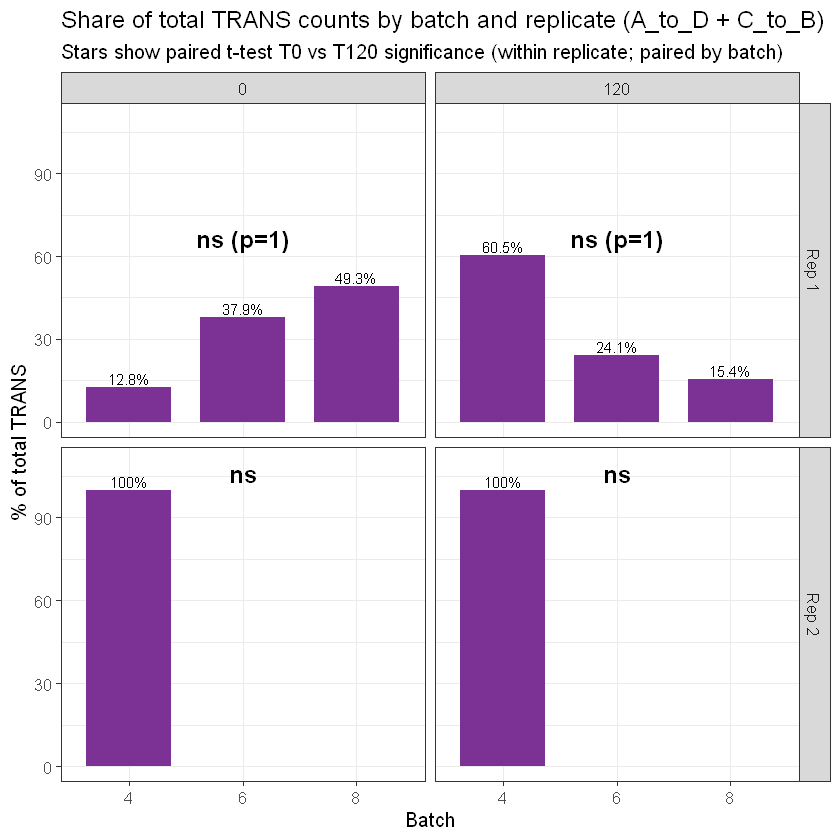

In [8]:
print(p_group4_trans_total)

**Figure 4A. Share of total TRANS counts by batch and replicate.**

- **Methods/Computation:** For each replicate-time stratum, TRANS totals were aggregated by batch and converted to percent share: $$\text{TRANS share}_{b} = 100\times\frac{T_b}{\sum_{b'} T_{b'}}$$ where $T_b$ is total TRANS count for batch $b$.
- **Biological relevance (with sources):** This quantifies how strongly non-cognate association activity is concentrated in specific contexts, which is relevant when interpreting DSB mobility/co-localization effects after damage induction [1,2].

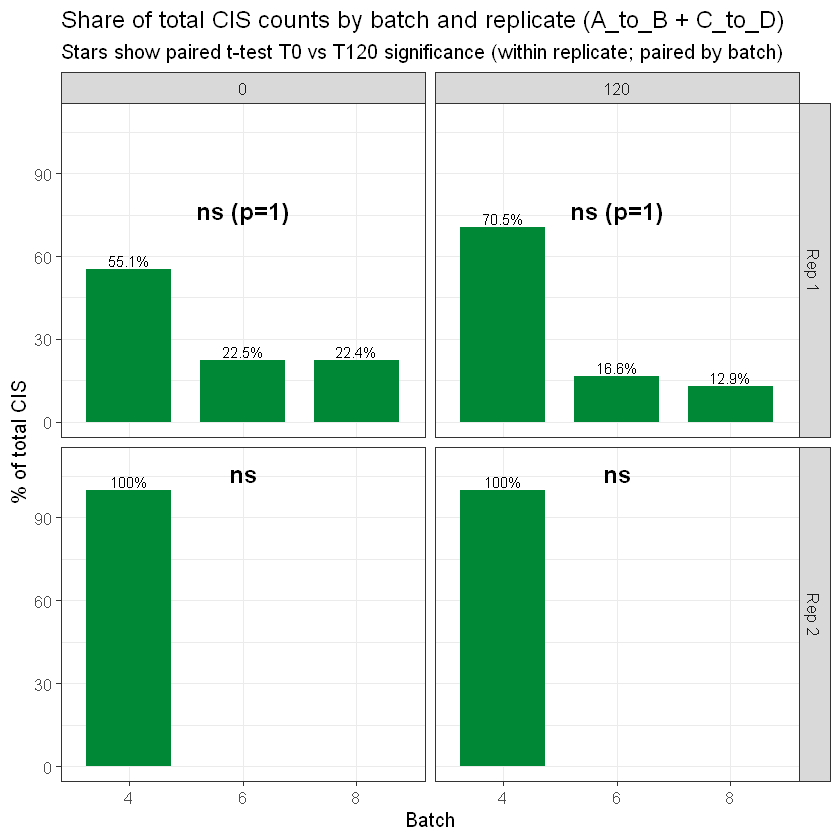

In [9]:
print(p_group4_cis_total)

**Figure 4B. Share of total CIS counts by batch and replicate.**

- **Methods/Computation:** CIS counts were converted to within-stratum batch shares: $$\text{CIS share}_{b} = 100\times\frac{C_b}{\sum_{b'} C_{b'}}$$ where $C_b$ is total CIS count for batch $b$.
- **Biological relevance (with sources):** CIS dominance is expected under canonical end joining; comparing CIS-share stability across batches helps separate robust repair-channel behavior from run-specific artifacts [1,3].

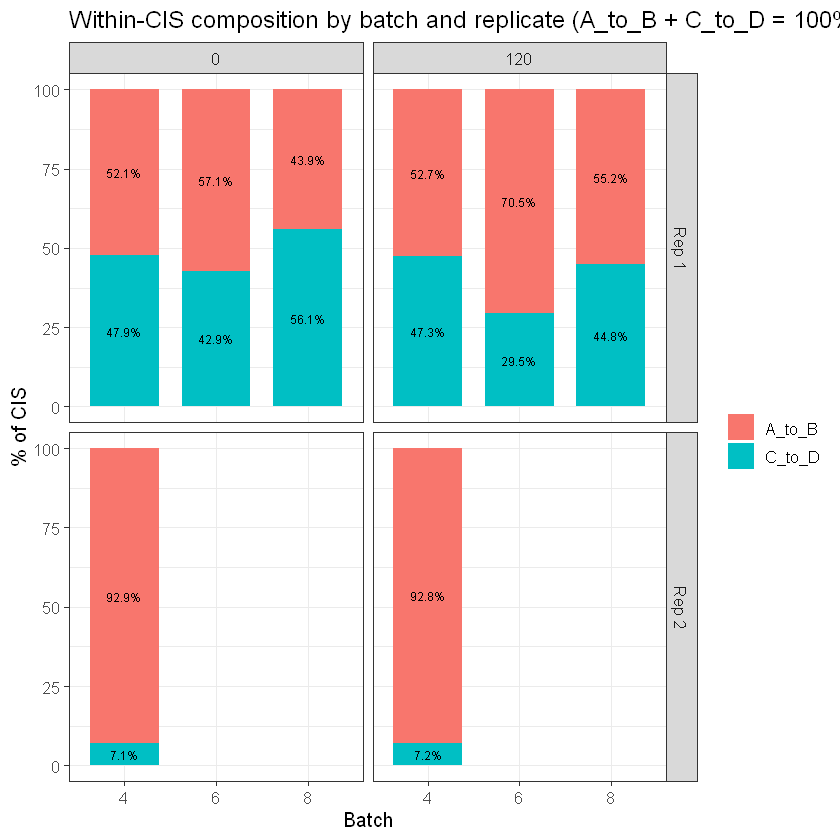

In [10]:
print(p_cis_comp_2only)

**Figure 4C. Within-CIS composition by batch and replicate.**

- **Methods/Computation:** CIS reads were normalized so components sum to 100%: $$p_{A\to B}=100\times\frac{N_{A\to B}}{N_{A\to B}+N_{C\to D}},\quad p_{C\to D}=100-p_{A\to B}.$$
- **Biological relevance (with sources):** Relative weighting of cognate channels reflects locus-specific partner preference under NHEJ and can reveal condition-dependent shifts in repair-associated pairing [1,2].

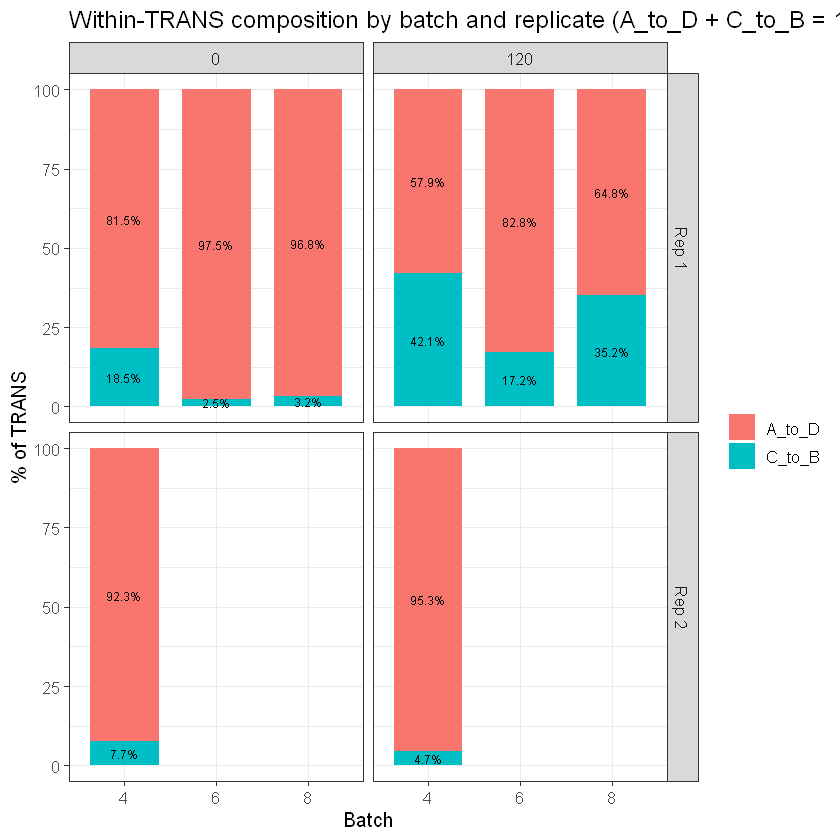

In [11]:
print(p_trans_comp_2only)

**Figure 4D. Within-TRANS composition by batch and replicate.**

- **Methods/Computation:** TRANS reads were normalized within channel: $$p_{A\to D}=100\times\frac{N_{A\to D}}{N_{A\to D}+N_{C\to B}},\quad p_{C\to B}=100-p_{A\to D}.$$
- **Biological relevance (with sources):** This compares non-cognate partner preference across conditions, consistent with hypotheses that post-damage motion and encounter dynamics can reshape DSB partner choice [2,7].

In [12]:
dat_norm_combo %>% head(10)

batch,replicate,time_point,DSB,allele,Cis_Location_Counts,Trans_Location_Counts,Total_Cis_Location_Counts,Total_Trans_Location_Counts,Total_Group_Counts,Percent_Cis_of_GroupTotal,Percent_Trans_of_GroupTotal,Percent_Location_in_Cis,Percent_Location_in_Trans
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,Rep 1,0,DSB1,Chr12_L01,23365,0,499775,0,499775,4.67510380,0,4.67510380,NA
4,Rep 1,0,DSB1,Chr12_L05,15119,0,499775,0,499775,3.02516132,0,3.02516132,NA
4,Rep 1,0,DSB1,Chr12_L07,19481,0,499775,0,499775,3.89795408,0,3.89795408,NA
4,Rep 1,0,DSB1,Chr12_L12,22779,0,499775,0,499775,4.55785103,0,4.55785103,NA
4,Rep 1,0,DSB1,Chr15_L01,27868,0,499775,0,499775,5.57610925,0,5.57610925,NA
4,Rep 1,0,DSB1,Chr15_L04,54,0,499775,0,499775,0.01080486,0,0.01080486,NA
4,Rep 1,0,DSB1,Chr15_L15,14456,0,499775,0,499775,2.89250163,0,2.89250163,NA
4,Rep 1,0,DSB1,Chr15_L17_2,28338,0,499775,0,499775,5.67015157,0,5.67015157,NA
4,Rep 1,0,DSB1,Chr15_L18,4689,0,499775,0,499775,0.93822220,0,0.93822220,NA


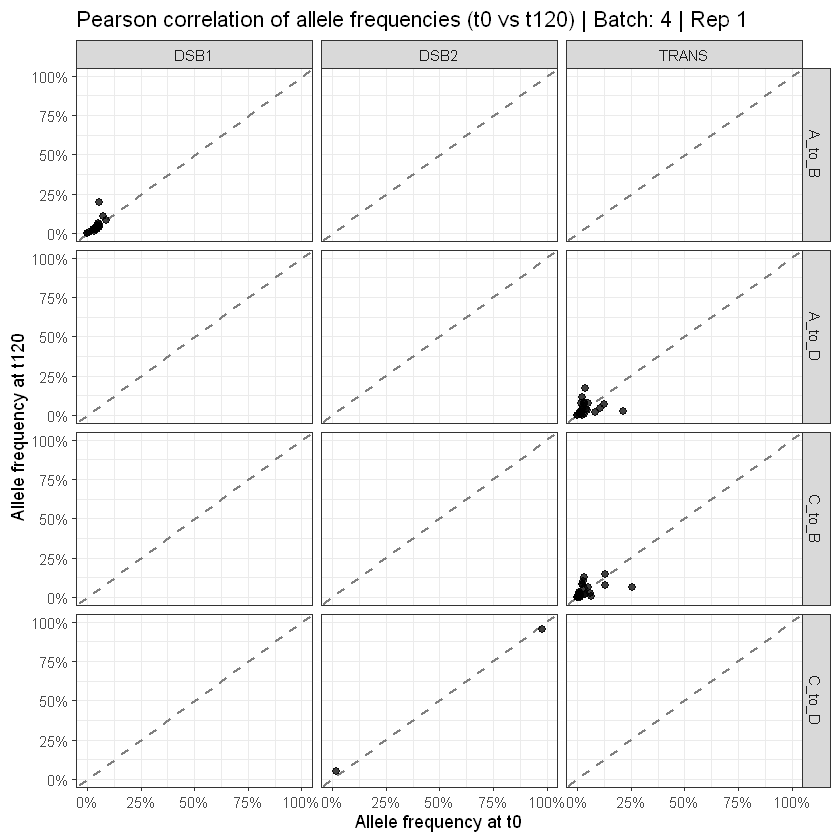

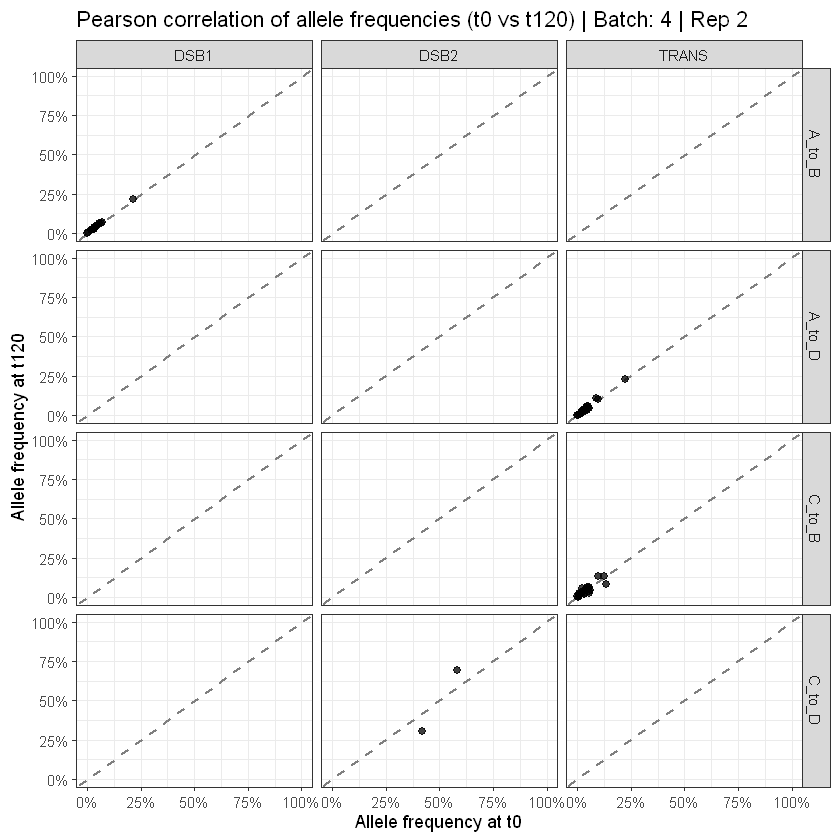

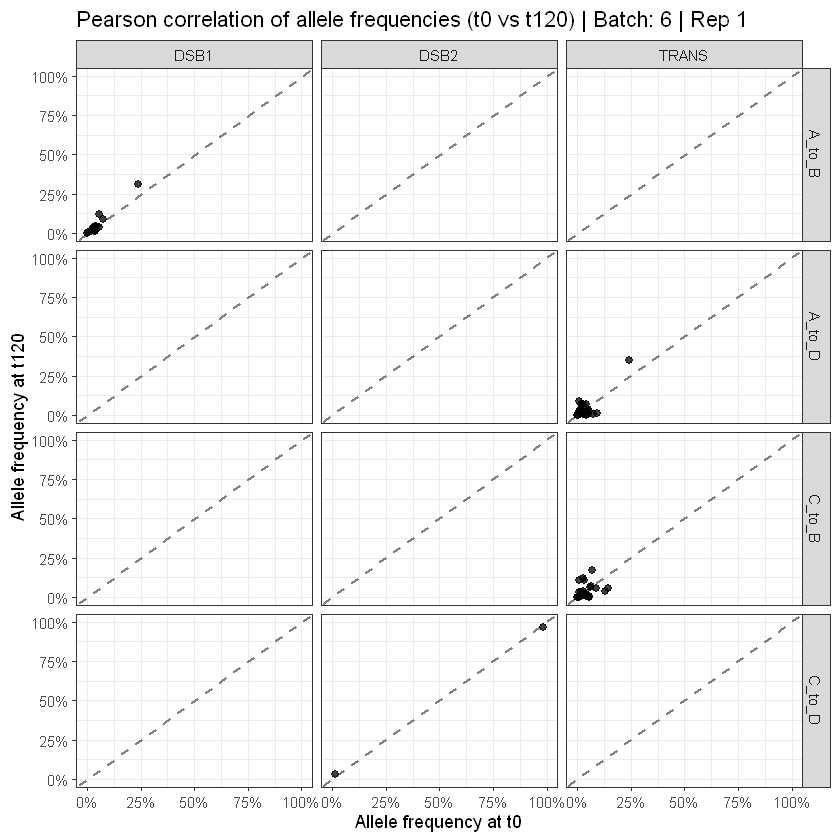

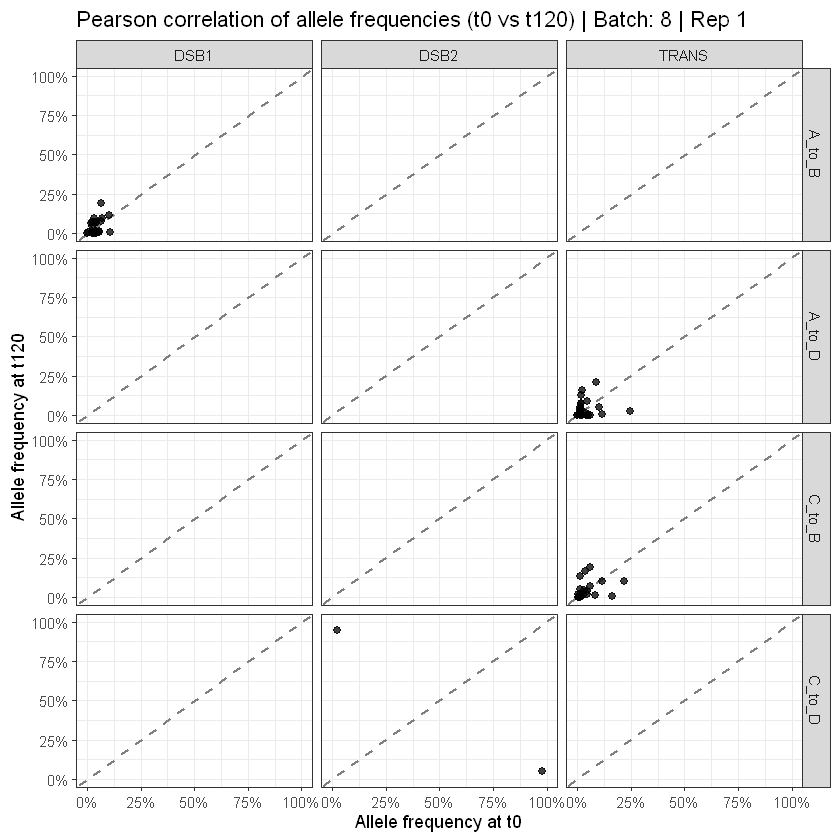

batch,replicate,DSB,cor_CIS_AF,cor_TRANS_AF,n_obs
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
4,Rep 1,DSB1,0.7330286,NA,24
4,Rep 1,DSB2,-1.0000000,NA,2
4,Rep 1,TRANS,NA,0.5593380,26
4,Rep 2,DSB1,0.2097350,NA,24
4,Rep 2,DSB2,1.0000000,NA,2
4,Rep 2,TRANS,NA,0.3655712,24
6,Rep 1,DSB1,0.4087059,NA,24
6,Rep 1,DSB2,-1.0000000,NA,2
6,Rep 1,TRANS,NA,0.4852722,24


Allele-frequency paired t-test (T0 vs T120, paired by allele, within batch x replicate x DSB):



# A tibble: 12 × 8
   batch replicate DSB   n_pairs mean_af_t0 mean_af_t120 p_value significance
   <chr> <chr>     <chr>   <int>      <dbl>        <dbl>   <dbl> <chr>       
 1 4     Rep 1     DSB1       24     0.0417       0.0417       1 ns          
 2 4     Rep 1     DSB2        2     0.5          0.5          1 ns          
 3 4     Rep 1     TRANS      26     0.0385       0.0385       1 ns          
 4 4     Rep 2     DSB1       24     0.0417       0.0417       1 ns          
 5 4     Rep 2     DSB2        2     0.5          0.5          1 ns          
 6 4     Rep 2     TRANS      24     0.0417       0.0417       1 ns          
 7 6     Rep 1     DSB1       24     0.0417       0.0417       1 ns          
 8 6     Rep 1     DSB2        2     0.5          0.5          1 ns          
 9 6     Rep 1     TRANS      24     0.0417       0.0417       1 ns          
10 8     Rep 1     DSB1       24     0.0417       0.0417       1 ns          
11 8     Rep 1     DSB2        2     0.5     

Log2FC CIS one-sample t-test (H0: mean log2FC = 0):



# A tibble: 8 × 7
  batch replicate DSB   n_obs mean_log2fc  p_value significance
  <chr> <chr>     <chr> <int>       <dbl>    <dbl> <chr>       
1 4     Rep 1     DSB1     24     -0.0952 4.48e- 1 ns          
2 4     Rep 1     DSB2      2      0.721  4.85e- 1 ns          
3 4     Rep 2     DSB1     24     -0.963  7.53e-19 ***         
4 4     Rep 2     DSB2      2     -1.02   2.16e- 1 ns          
5 6     Rep 1     DSB1     24     -0.689  8.20e- 5 ***         
6 6     Rep 1     DSB2      2     -0.703  4.27e- 1 ns          
7 8     Rep 1     DSB1     24     -1.77   1.25e- 3 **          
8 8     Rep 1     DSB2      2     -0.823  8.93e- 1 ns          


Log2FC TRANS one-sample t-test (H0: mean log2FC = 0):



# A tibble: 4 × 7
  batch replicate DSB   n_obs mean_log2fc      p_value significance
  <chr> <chr>     <chr> <int>       <dbl>        <dbl> <chr>       
1 4     Rep 1     TRANS    26       2.77  0.0000000349 ***         
2 4     Rep 2     TRANS    24      -0.384 0.00000796   ***         
3 6     Rep 1     TRANS    24      -0.364 0.344        ns          
4 8     Rep 1     TRANS    24      -1.55  0.0125       *           


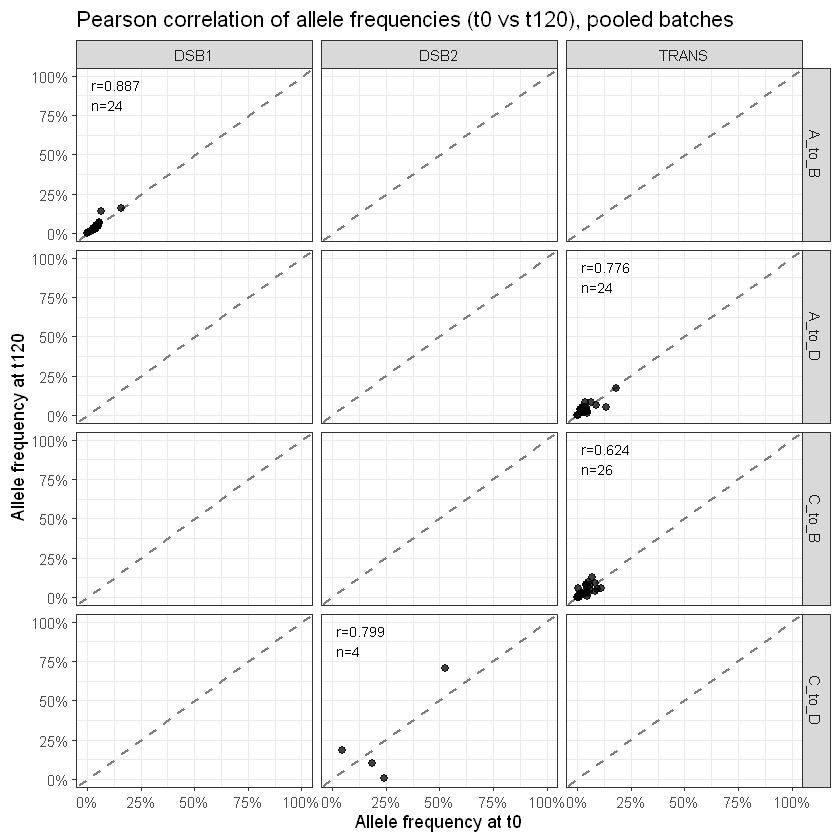

In [13]:
# ---- Sections 4.1, 5, 6: AF correlations + fold-change + summary correlation table ----
# Allele frequency (CIS + TRANS) per group
my_summarize_allelefreq <- function(dat) {
  by_allele <- dat %>%
    group_by(batch, replicate, time_point, DSB, allele) %>%
    summarise(
      Cis_Counts = sum(count[combo %in% cis_combos], na.rm = TRUE),
      Trans_Counts = sum(count[combo %in% trans_combos], na.rm = TRUE),
      Allele_Total = Cis_Counts + Trans_Counts,
      .groups = 'drop'
    )

  totals <- by_allele %>%
    group_by(batch, replicate, time_point, DSB) %>%
    summarise(
      Total_Cis = sum(Cis_Counts, na.rm = TRUE),
      Total_Trans = sum(Trans_Counts, na.rm = TRUE),
      Total_All = Total_Cis + Total_Trans,
      .groups = 'drop'
    )

  by_allele %>%
    left_join(totals, by = c('batch', 'replicate', 'time_point', 'DSB')) %>%
    mutate(Allele_Frequency = if_else(Total_All > 0, Allele_Total / Total_All, NA_real_))
}

safe_cor <- function(x, y) {
  idx <- is.finite(x) & is.finite(y)
  if (sum(idx) < 2) return(NA_real_)
  suppressWarnings(cor(x[idx], y[idx], method = 'pearson'))
}

dat_allele_freq <- my_summarize_allelefreq(dat_focus)

# 4.1 Pearson correlation of allele frequencies t0 vs t120
timepoints_compare <- c(0, 120)

dat_allele_freq_combo <- dat_focus %>%
  group_by(batch, replicate, DSB, combo, time_point, allele) %>%
  summarise(Allele_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(batch, replicate, DSB, combo, time_point) %>%
  mutate(
    Total_Counts = sum(Allele_Counts, na.rm = TRUE),
    Allele_Frequency = if_else(Total_Counts > 0, Allele_Counts / Total_Counts, NA_real_)
  ) %>%
  ungroup() %>%
  filter(time_point %in% timepoints_compare)

dat_wide_af <- dat_allele_freq_combo %>%
  select(batch, replicate, DSB, combo, allele, time_point, Allele_Frequency) %>%
  mutate(tp = paste0('t', time_point)) %>%
  select(-time_point) %>%
  pivot_wider(names_from = tp, values_from = Allele_Frequency)

cor_stats <- dat_wide_af %>%
  group_by(batch, replicate, DSB, combo) %>%
  summarise(
    n_pairs = sum(is.finite(t0) & is.finite(t120)),
    r = safe_cor(t0, t120),
    .groups = 'drop'
  ) %>%
  mutate(label = if_else(is.na(r), paste0('n=', n_pairs), paste0('r=', round(r, 3), '\n', 'n=', n_pairs)))

plot_cor_by_batch <- function(df_wide, df_stats) {
  keys <- df_wide %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    dfb <- df_wide %>% filter(batch == b, replicate == r)
    if (nrow(dfb) == 0) next

    statsb <- df_stats %>% filter(batch == b, replicate == r) %>% mutate(x = 0.02, y = 0.98)

    p <- ggplot(dfb, aes(x = t0, y = t120)) +
      geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
      geom_point(alpha = 0.75, size = 1.8) +
      facet_grid(combo ~ DSB) +
      geom_text(data = statsb, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 0, vjust = 1, size = 3) +
      scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
      scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
      theme_bw(base_size = 11) +
      labs(
        title = paste0('Pearson correlation of allele frequencies (t0 vs t120) | Batch: ', b, ' | ', r),
        x = 'Allele frequency at t0',
        y = 'Allele frequency at t120'
      )
    print(p)
  }
}

if (nrow(dat_wide_af) > 0) plot_cor_by_batch(dat_wide_af, cor_stats)

# Pooled across batches
dat_allele_freq_combo_overall <- dat_focus %>%
  group_by(DSB, combo, time_point, allele) %>%
  summarise(Allele_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, combo, time_point) %>%
  mutate(
    Total_Counts = sum(Allele_Counts, na.rm = TRUE),
    Allele_Frequency = if_else(Total_Counts > 0, Allele_Counts / Total_Counts, NA_real_)
  ) %>%
  ungroup() %>%
  filter(time_point %in% timepoints_compare)

dat_wide_overall <- dat_allele_freq_combo_overall %>%
  select(DSB, combo, allele, time_point, Allele_Frequency) %>%
  mutate(tp = paste0('t', time_point)) %>%
  select(-time_point) %>%
  pivot_wider(names_from = tp, values_from = Allele_Frequency)

cor_stats_overall <- dat_wide_overall %>%
  group_by(DSB, combo) %>%
  summarise(
    n_pairs = sum(is.finite(t0) & is.finite(t120)),
    r = safe_cor(t0, t120),
    .groups = 'drop'
  ) %>%
  mutate(
    label = if_else(is.na(r), paste0('n=', n_pairs), paste0('r=', round(r, 3), '\n', 'n=', n_pairs)),
    x = 0.02,
    y = 0.98
  )

if (nrow(dat_wide_overall) > 0) {
  p_overall_af_corr <- ggplot(dat_wide_overall, aes(x = t0, y = t120)) +
    geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
    geom_point(alpha = 0.75, size = 1.8) +
    facet_grid(combo ~ DSB) +
    geom_text(data = cor_stats_overall, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 0, vjust = 1, size = 3) +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    theme_bw(base_size = 11) +
    labs(title = 'Pearson correlation of allele frequencies (t0 vs t120), pooled batches', x = 'Allele frequency at t0', y = 'Allele frequency at t120')
  print(p_overall_af_corr)
}

# Section 5: Fold-change calculations (120 / 0)
eps <- 1e-6

dat_fc_cis <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Cis_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = Cis_Location_Counts, values_fill = 0) %>%
  mutate(
    FoldChange_Cis_120_vs_0 = fc_ratio(`120`, `0`, eps = eps),
    Log2FC_Cis_120_vs_0 = log2(FoldChange_Cis_120_vs_0)
  )

dat_fc_trans <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Trans_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = Trans_Location_Counts, values_fill = 0) %>%
  mutate(
    FoldChange_Trans_120_vs_0 = fc_ratio(`120`, `0`, eps = eps),
    Log2FC_Trans_120_vs_0 = log2(FoldChange_Trans_120_vs_0)
  )

# Section 6: Correlation of log2FC vs AF
dat_wide <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, DSB, allele, time_point, Cis_Location_Counts, Trans_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = c(Cis_Location_Counts, Trans_Location_Counts), values_fill = 0) %>%
  mutate(
    log2FC_CIS = log2(fc_ratio(Cis_Location_Counts_120, Cis_Location_Counts_0, eps = eps)),
    log2FC_TRANS = log2(fc_ratio(Trans_Location_Counts_120, Trans_Location_Counts_0, eps = eps))
  )

dat_fc_af <- dat_wide %>%
  inner_join(
    dat_allele_freq %>% filter(time_point == 120) %>% select(batch, replicate, DSB, allele, Allele_Frequency),
    by = c('batch', 'replicate', 'DSB', 'allele')
  ) %>%
  filter(!is.na(Allele_Frequency) & Allele_Frequency > 0)

cor_summary <- dat_fc_af %>%
  group_by(batch, replicate, DSB) %>%
  summarise(
    cor_CIS_AF = safe_cor(log2FC_CIS, Allele_Frequency),
    cor_TRANS_AF = safe_cor(log2FC_TRANS, Allele_Frequency),
    n_obs = n(),
    .groups = 'drop'
  )

cor_summary

# ---- T-tests for fold changes and allele frequency (T0 vs T120) ----

# (1) Paired t-test: AF at T0 vs T120 paired by allele, within batch x replicate x DSB
run_af_paired_ttest <- function(df_af) {
  df_af %>%
    filter(time_point %in% c(0, 120), is.finite(Allele_Frequency)) %>%
    select(batch, replicate, DSB, allele, time_point, Allele_Frequency) %>%
    pivot_wider(names_from = time_point, values_from = Allele_Frequency, names_prefix = 't') %>%
    filter(is.finite(t0), is.finite(t120)) %>%
    group_by(batch, replicate, DSB) %>%
    group_modify(~ {
      d <- .x
      n <- nrow(d)
      p <- NA_real_
      if (n >= 2) {
        tt <- tryCatch(t.test(d$t120, d$t0, paired = TRUE), error = function(e) NULL)
        if (!is.null(tt)) p <- as.numeric(tt$p.value)
      }
      tibble::tibble(
        n_pairs    = n,
        mean_af_t0   = mean(d$t0,   na.rm = TRUE),
        mean_af_t120 = mean(d$t120, na.rm = TRUE),
        p_value    = p
      )
    }) %>%
    ungroup() %>%
    mutate(significance = sig_stars(p_value))
}

# (2) One-sample t-test: mean log2FC vs 0 (per batch x replicate x DSB, across alleles)
run_log2fc_onesample_ttest <- function(df_fc, log2fc_col) {
  df_fc %>%
    filter(is.finite(.data[[log2fc_col]])) %>%
    group_by(batch, replicate, DSB) %>%
    group_modify(~ {
      d <- .x
      n <- nrow(d)
      p <- NA_real_
      if (n >= 2) {
        tt <- tryCatch(t.test(d[[log2fc_col]], mu = 0), error = function(e) NULL)
        if (!is.null(tt)) p <- as.numeric(tt$p.value)
      }
      tibble::tibble(
        n_obs        = n,
        mean_log2fc  = mean(d[[log2fc_col]], na.rm = TRUE),
        p_value      = p
      )
    }) %>%
    ungroup() %>%
    mutate(significance = sig_stars(p_value))
}

ttest_af_t0_t120   <- run_af_paired_ttest(dat_allele_freq)
ttest_log2fc_cis   <- run_log2fc_onesample_ttest(dat_fc_cis,   'Log2FC_Cis_120_vs_0')
ttest_log2fc_trans <- run_log2fc_onesample_ttest(dat_fc_trans,  'Log2FC_Trans_120_vs_0')

message('Allele-frequency paired t-test (T0 vs T120, paired by allele, within batch x replicate x DSB):')
print(ttest_af_t0_t120)
message('Log2FC CIS one-sample t-test (H0: mean log2FC = 0):')
print(ttest_log2fc_cis)
message('Log2FC TRANS one-sample t-test (H0: mean log2FC = 0):')
print(ttest_log2fc_trans)


**Figure set (Sections 4.1–6). AF correlations, fold-change metrics, and abundance-shift summaries.**

- **Methods/Computation:** Allele-frequency concordance uses Pearson correlation $$r=\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2}\sqrt{\sum_i (y_i-\bar{y})^2}},$$ with $x_i=f_i(t0)$ and $y_i=f_i(t120)$. Fold-change and stabilized log-ratio are $$\mathrm{FC}_i=\frac{n_i(t120)+\epsilon}{n_i(t0)+\epsilon},\quad \log_2\mathrm{FC}_i=\log_2\!\left(\frac{n_i(t120)+\epsilon}{n_i(t0)+\epsilon}\right).$$
- **Biological relevance (with sources):** High $r$ suggests preserved association hierarchy; large $|\log_2\mathrm{FC}|$ indicates selective post-induction redistribution of allele associations, informative for DSB-end-joining partner choice [1,2,4].

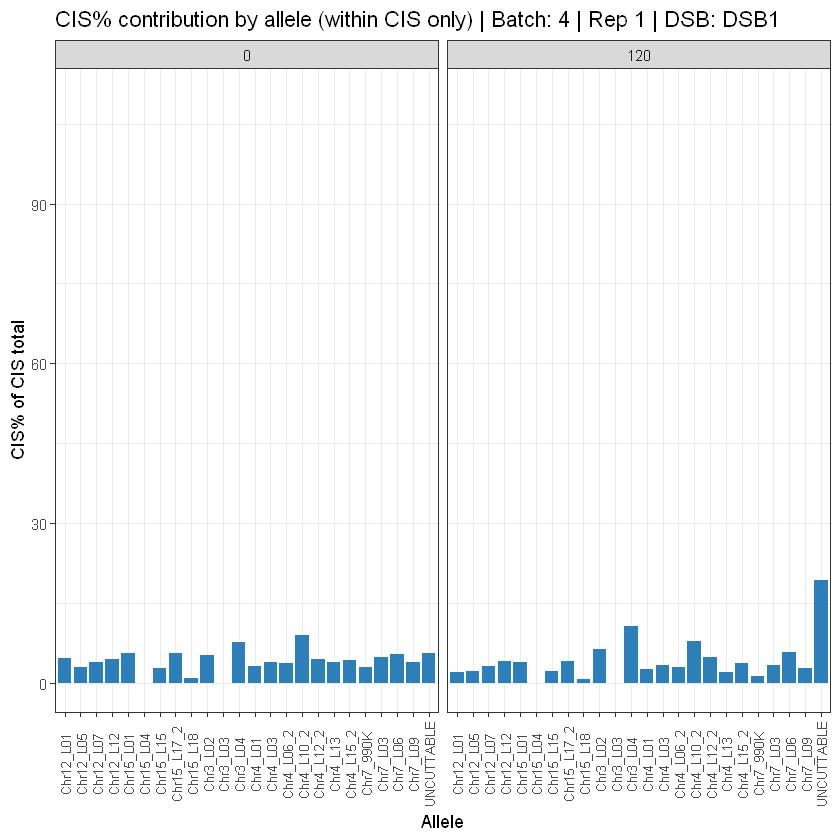

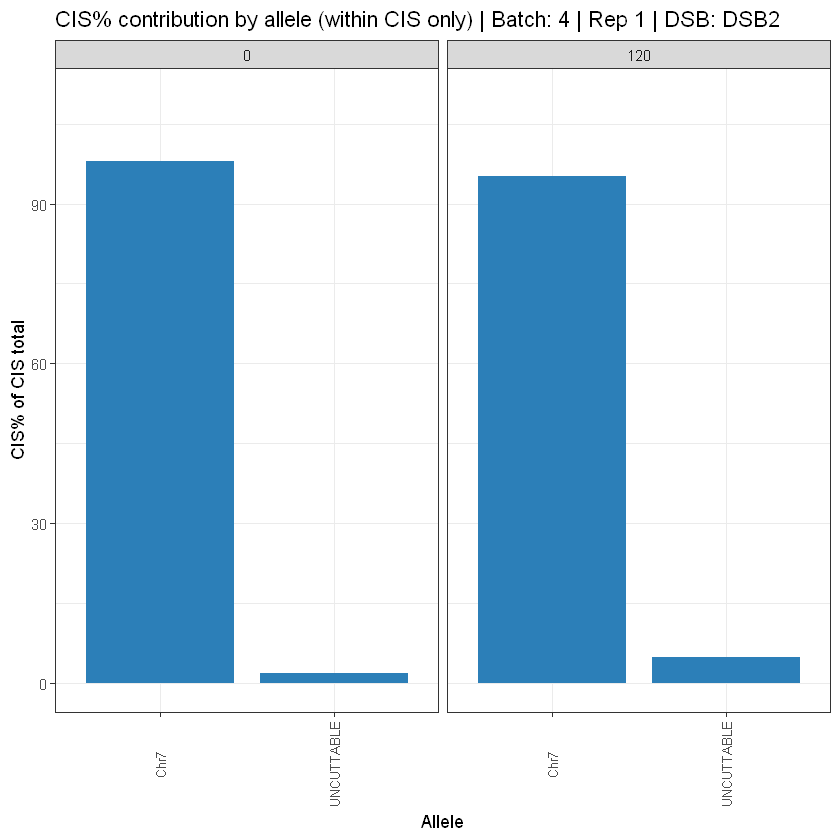

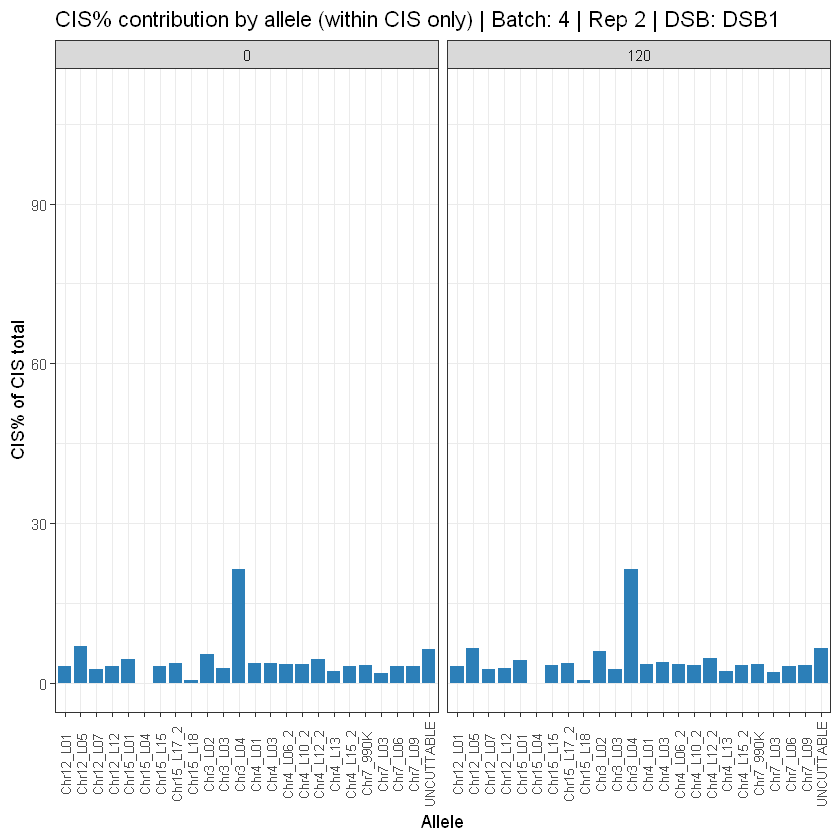

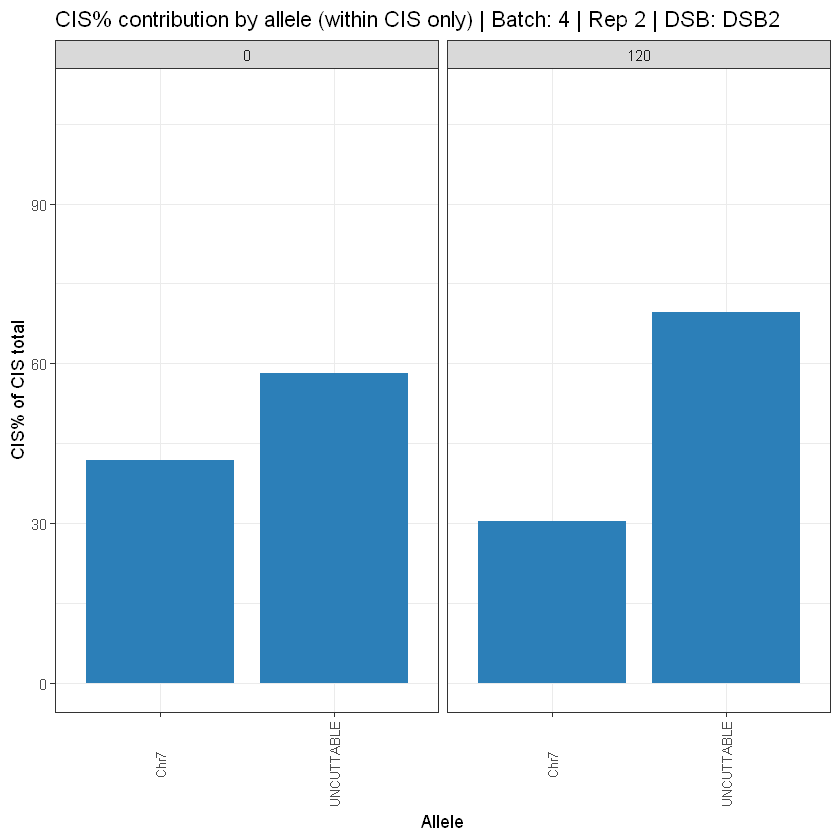

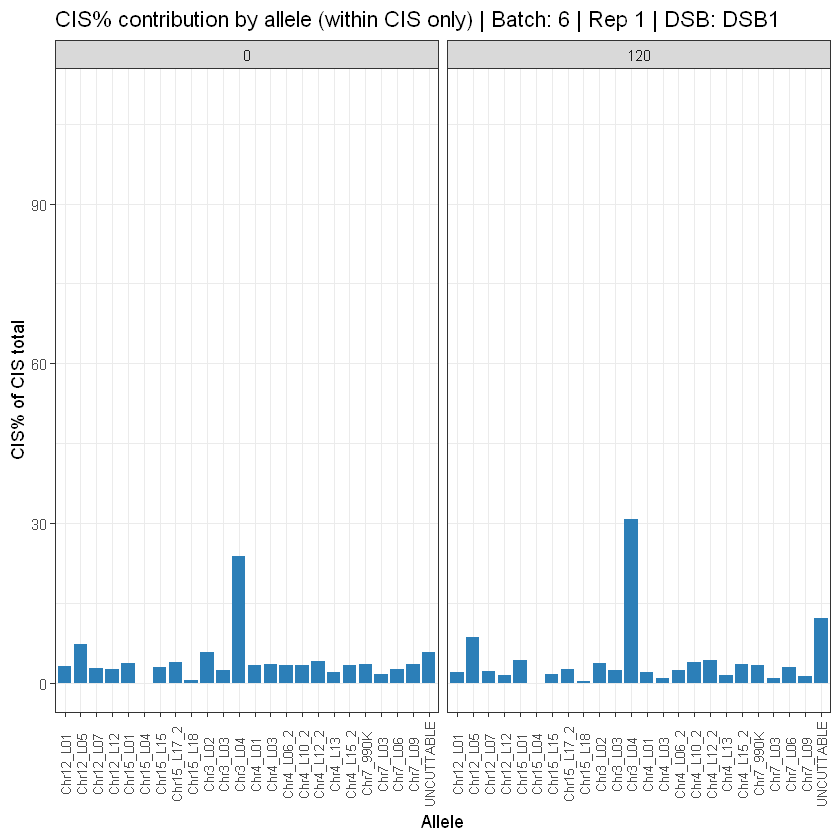

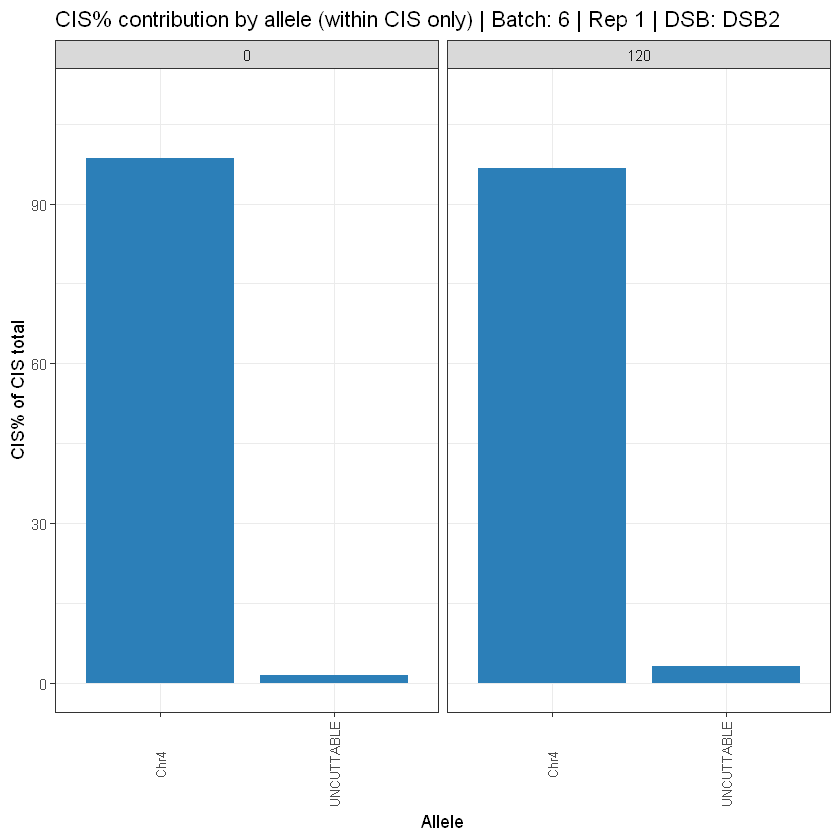

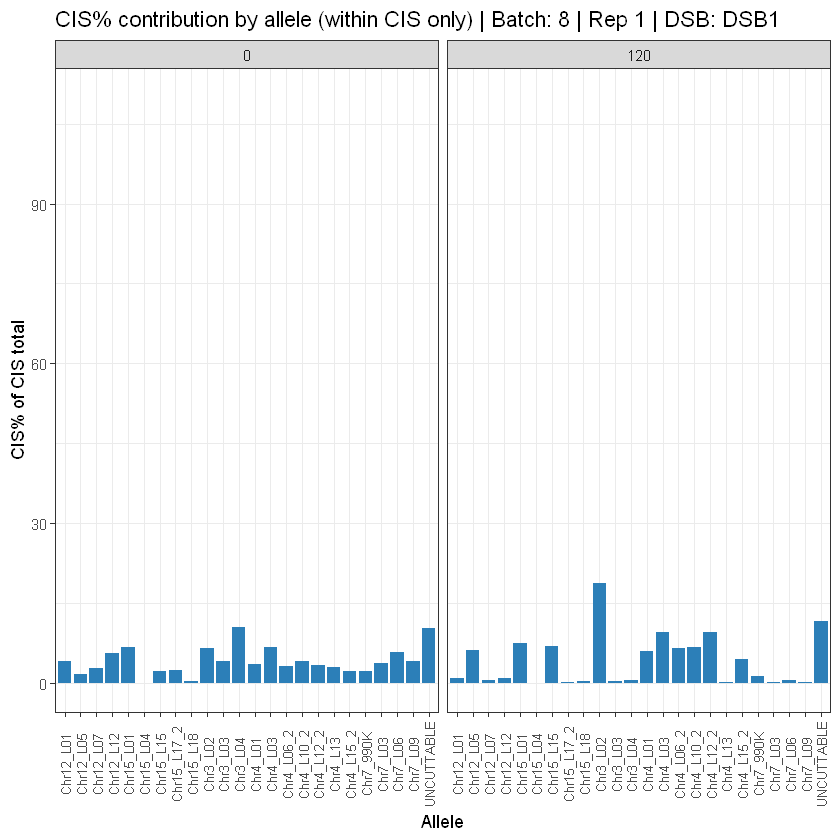

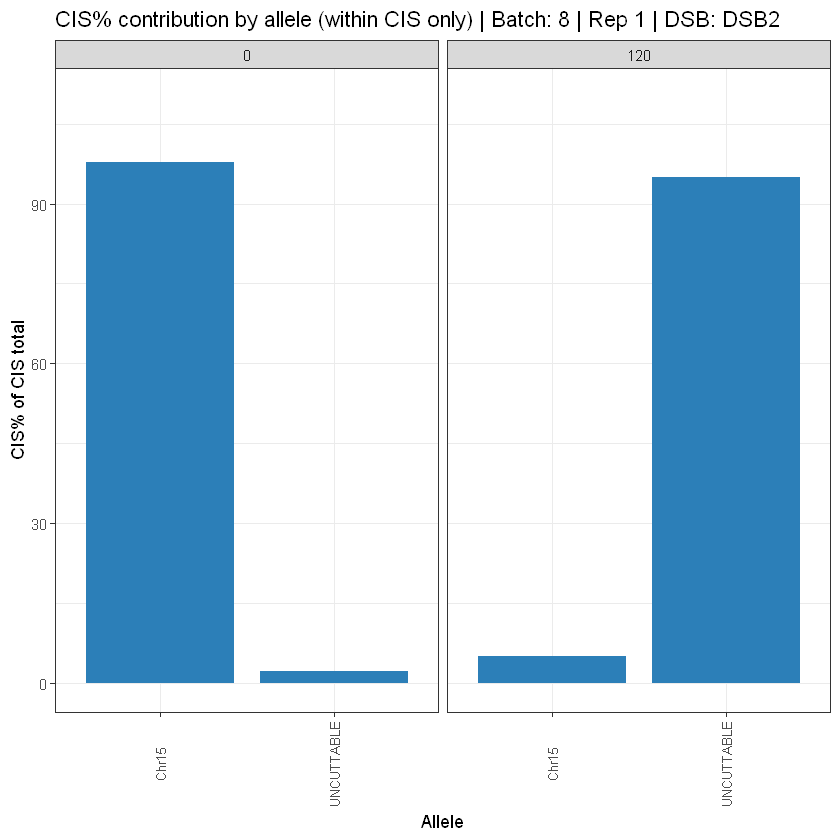

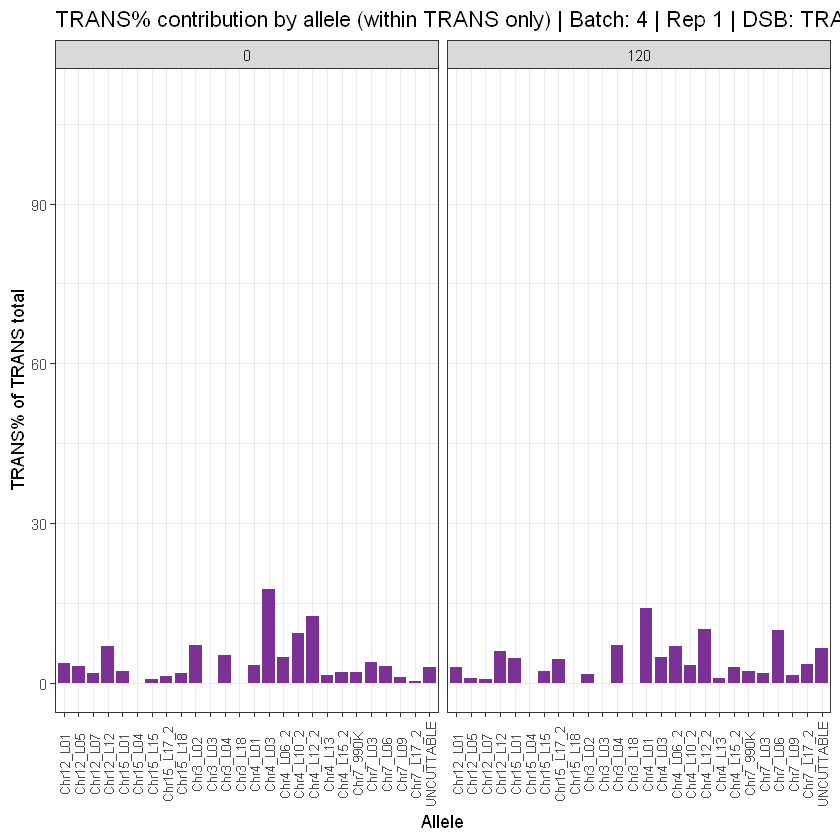

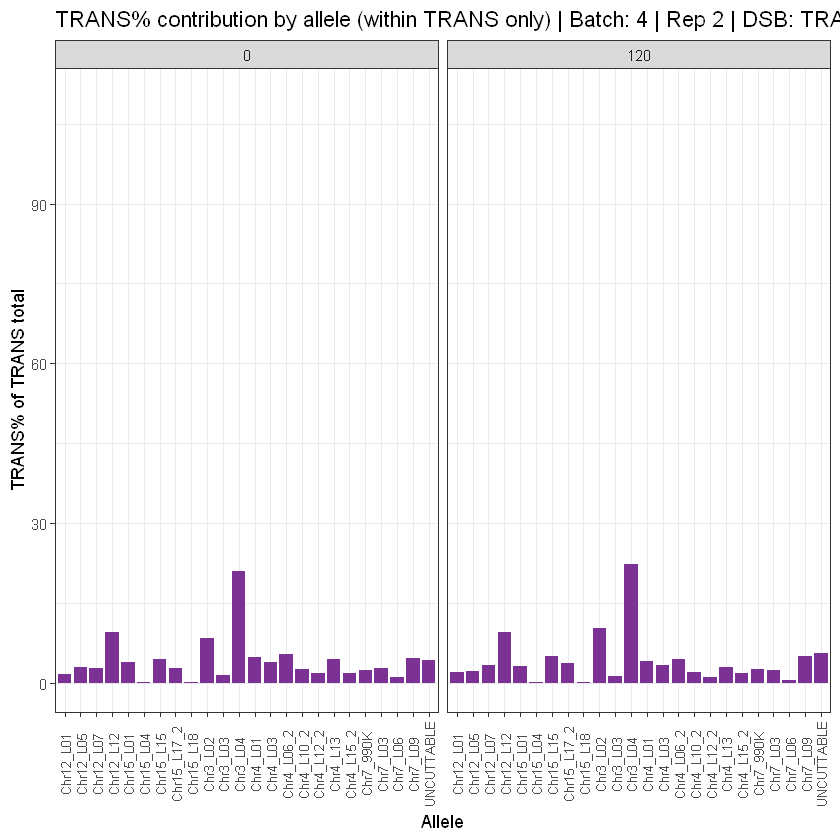

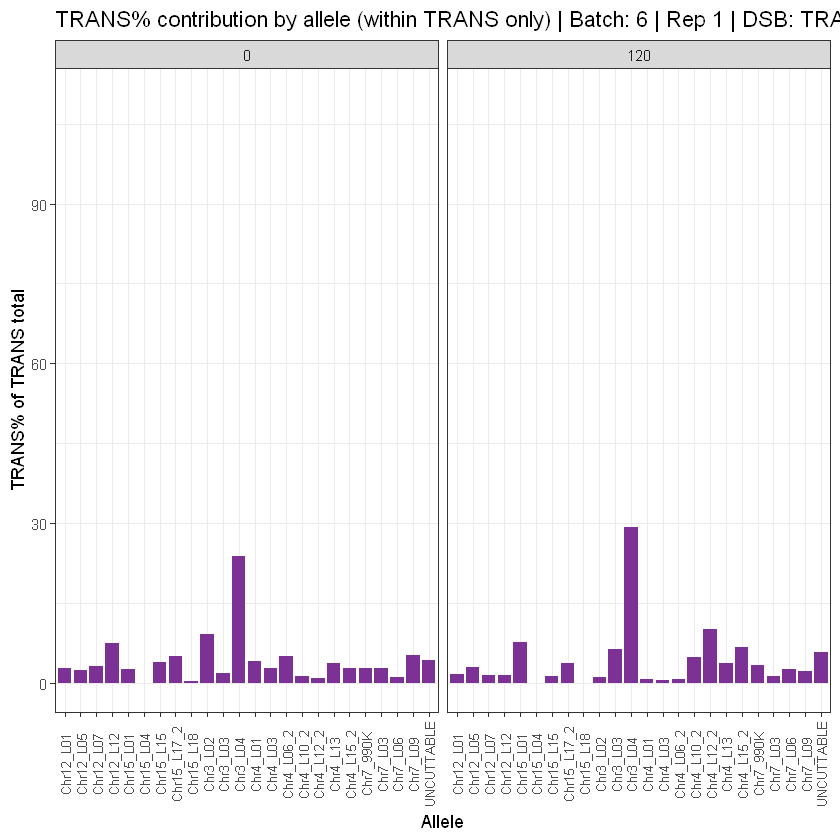

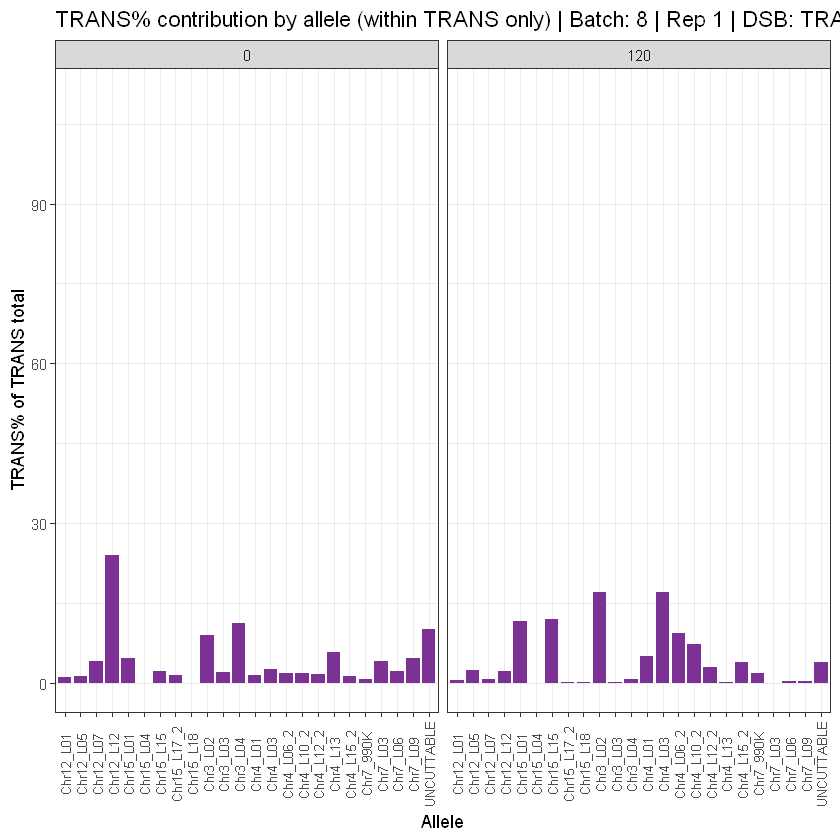

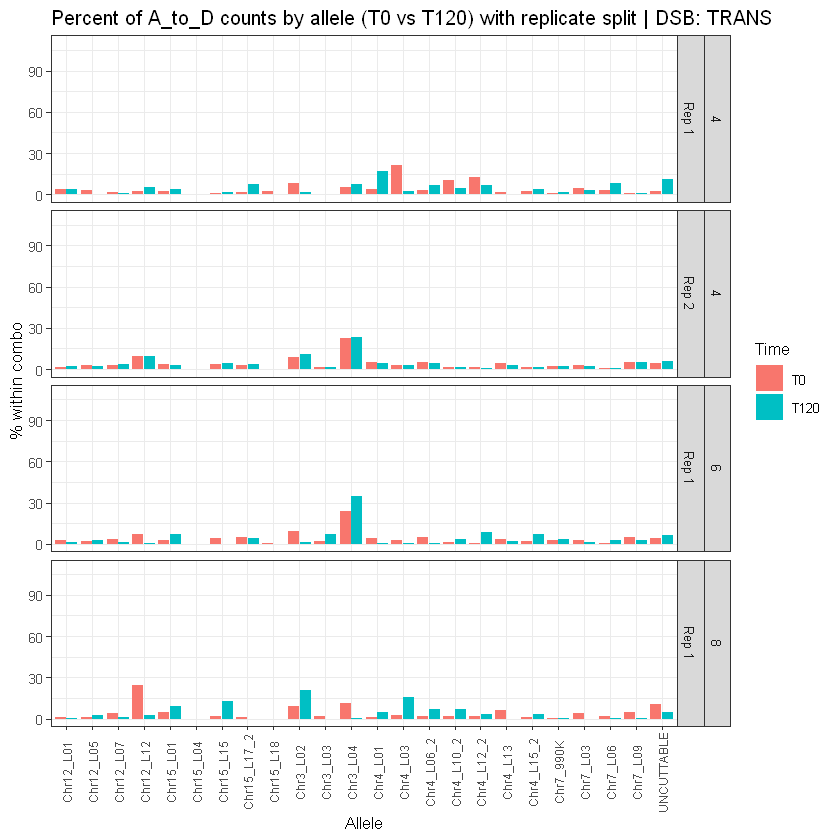

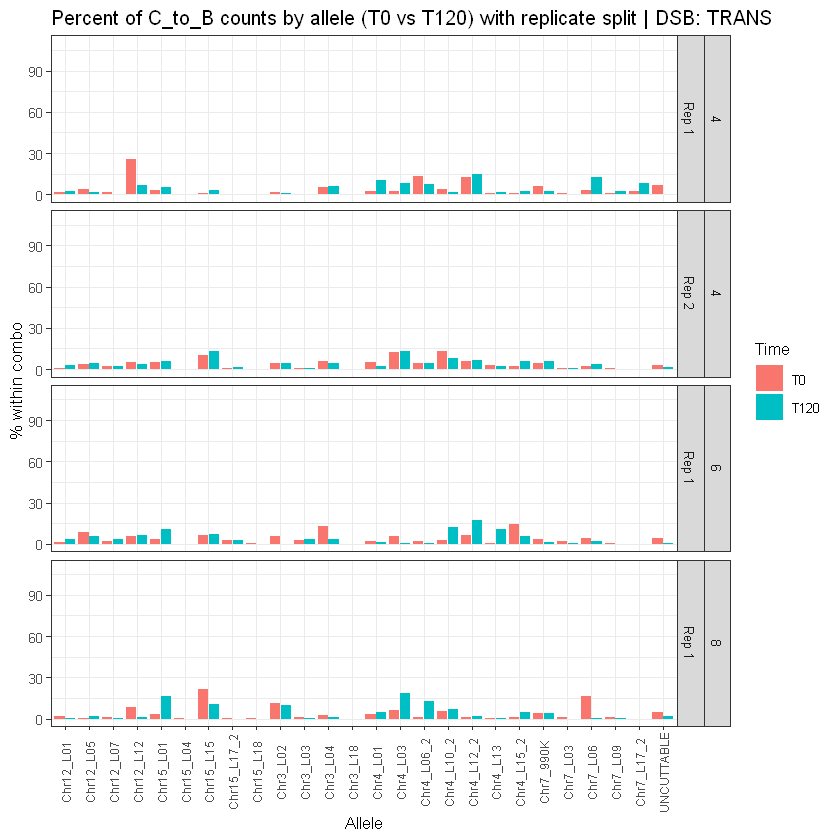

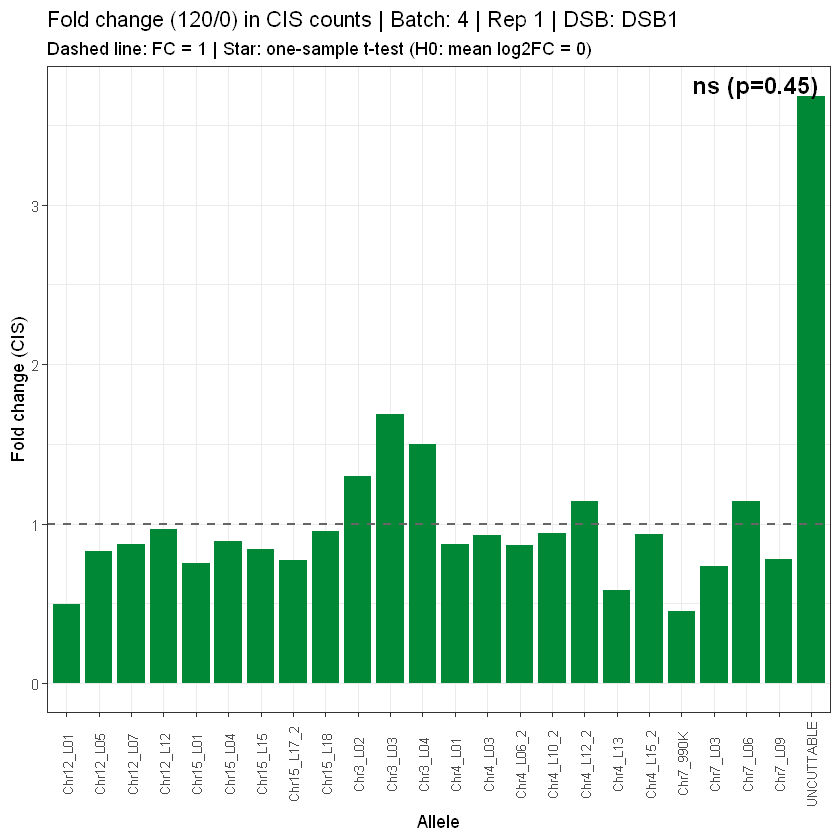

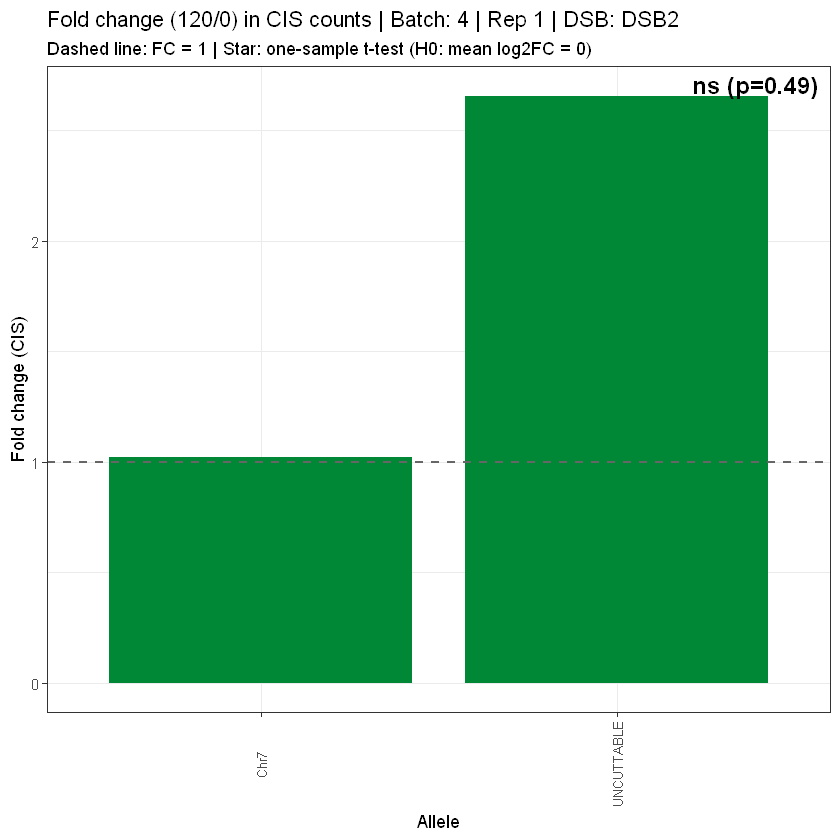

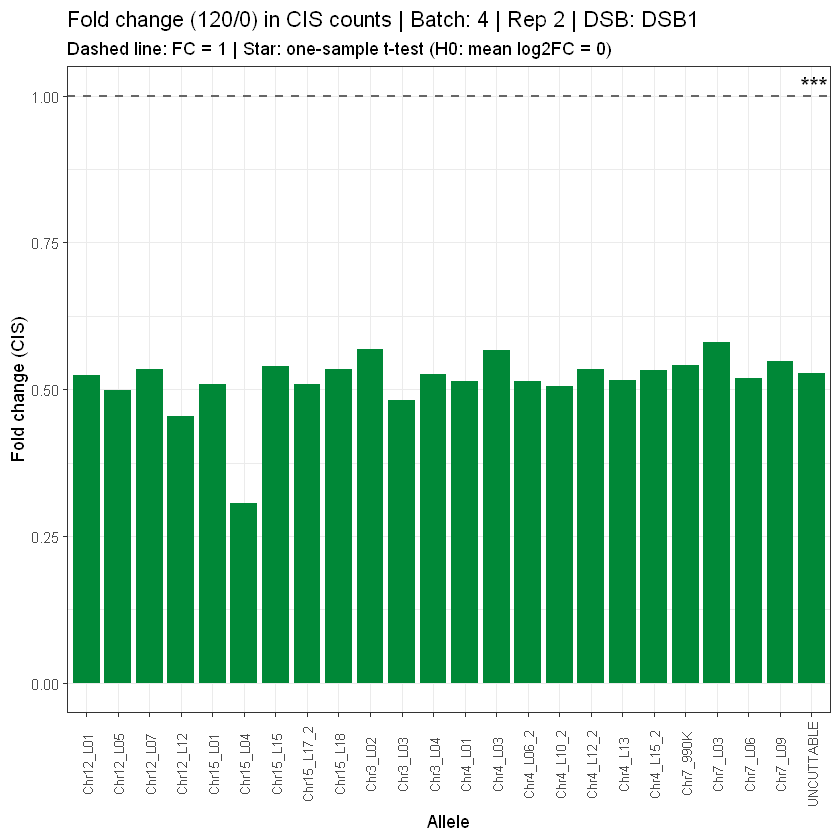

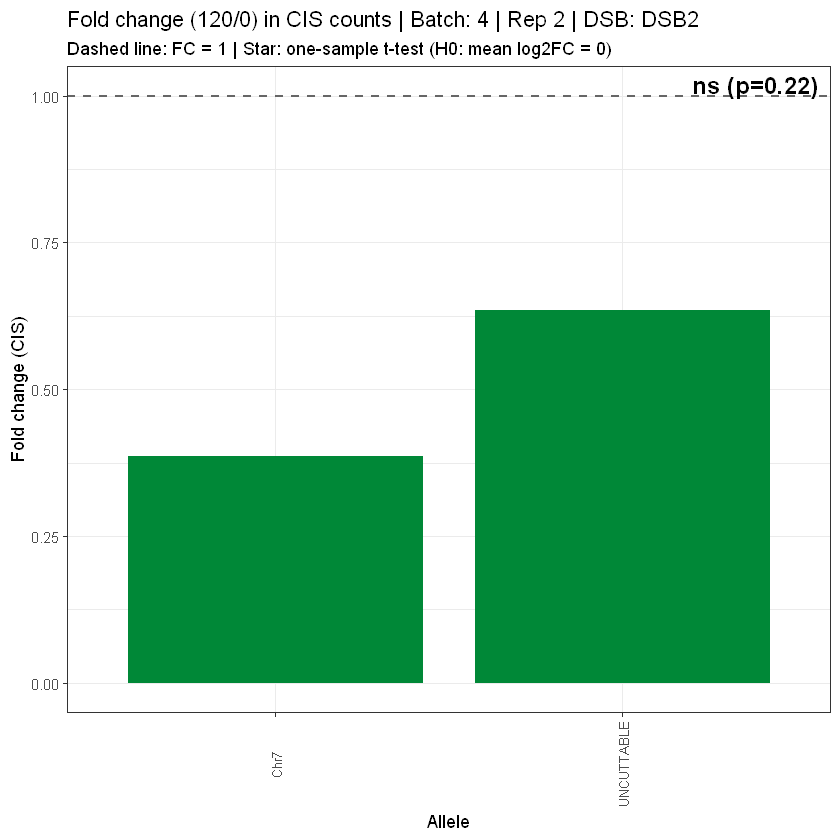

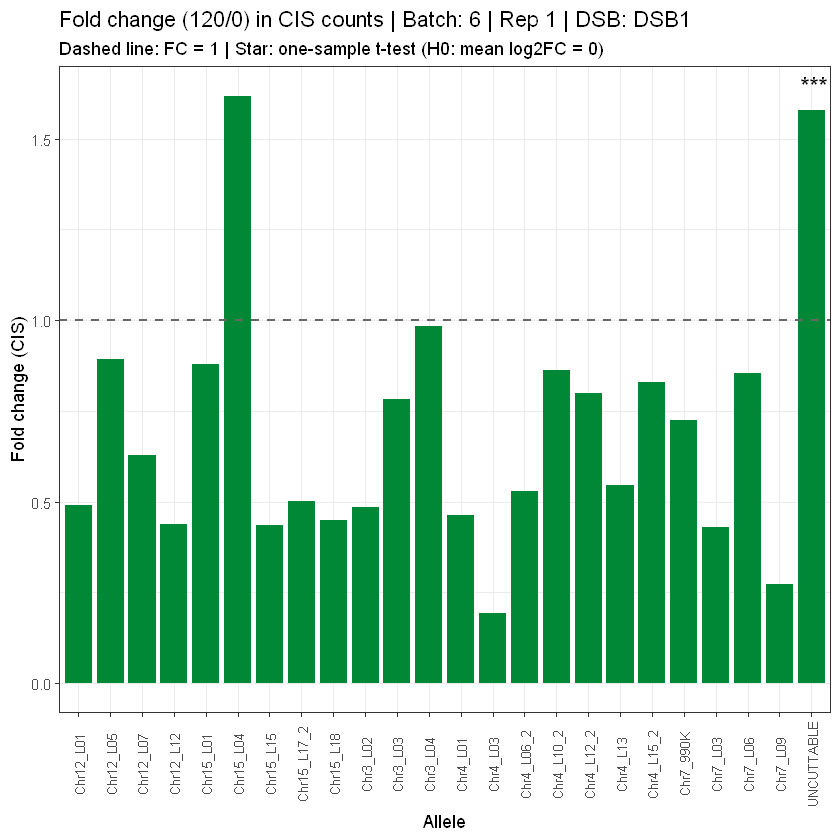

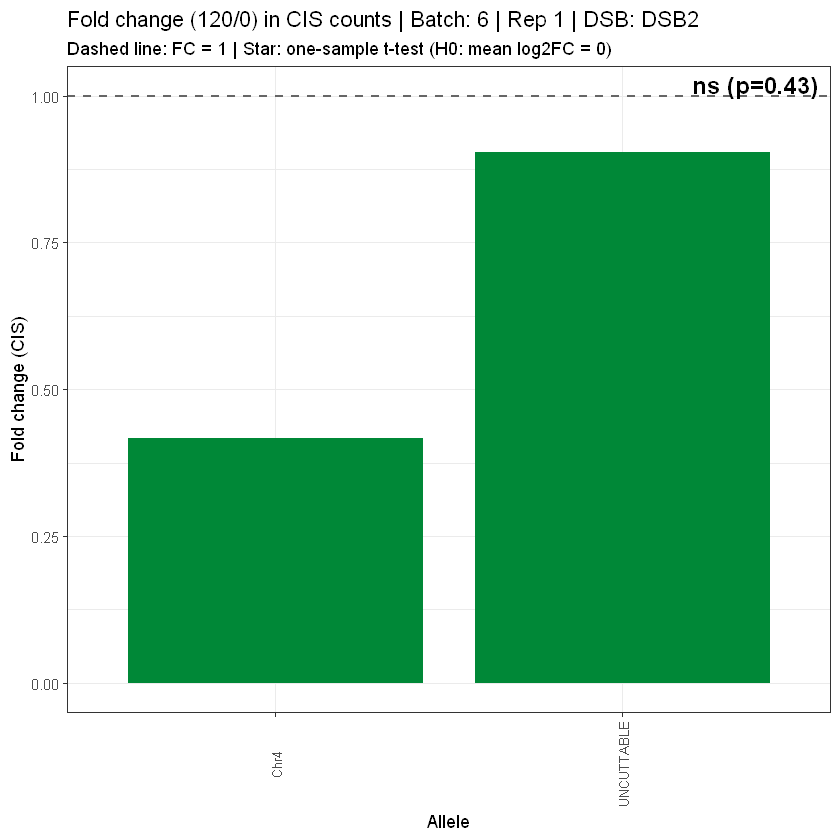

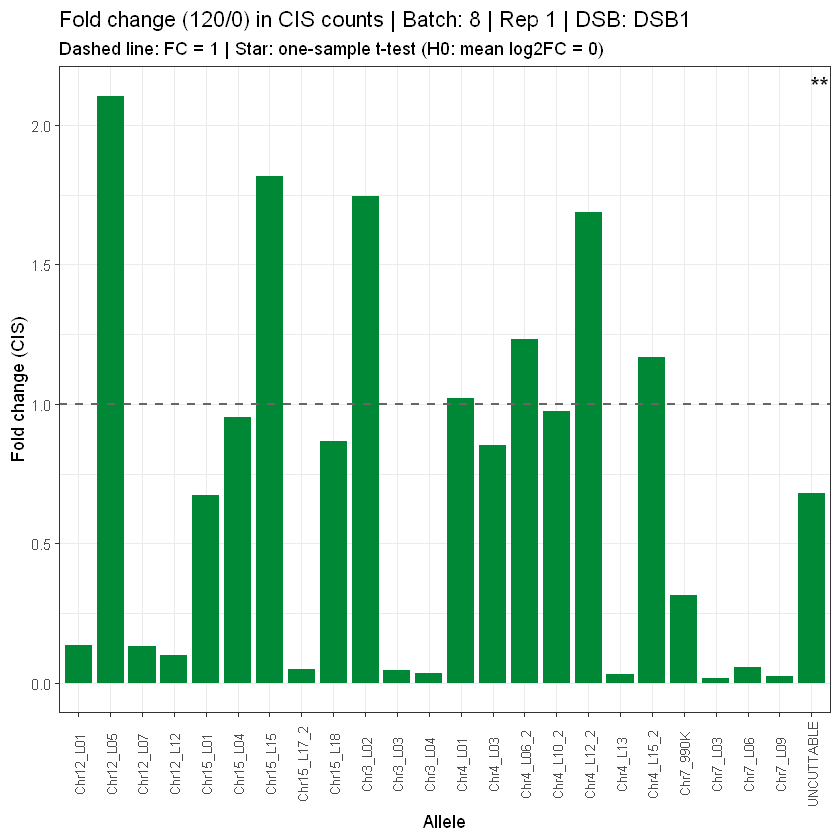

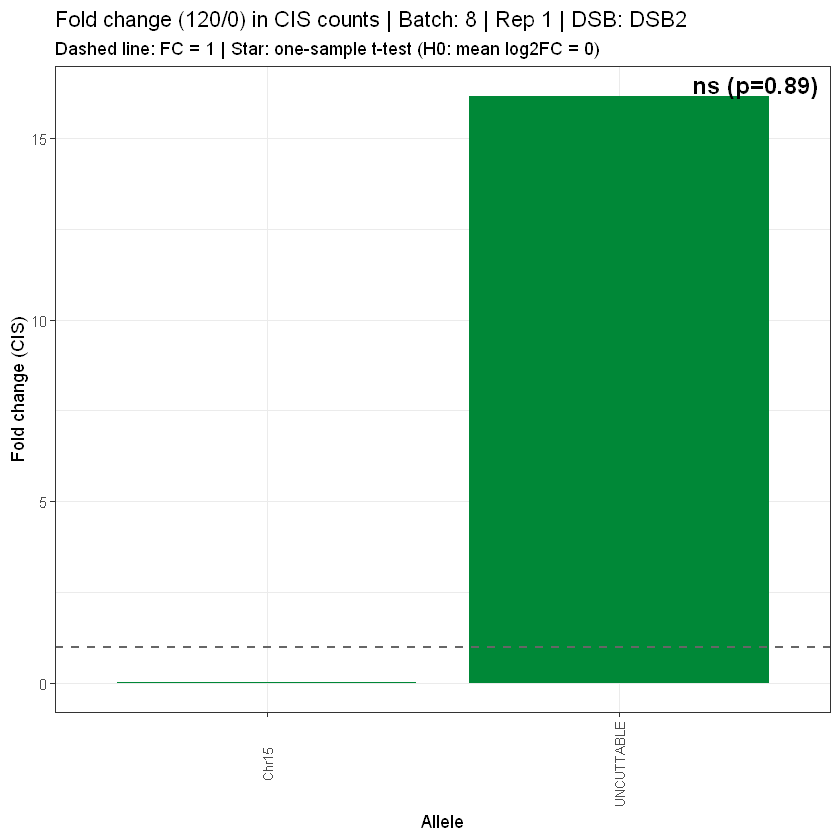

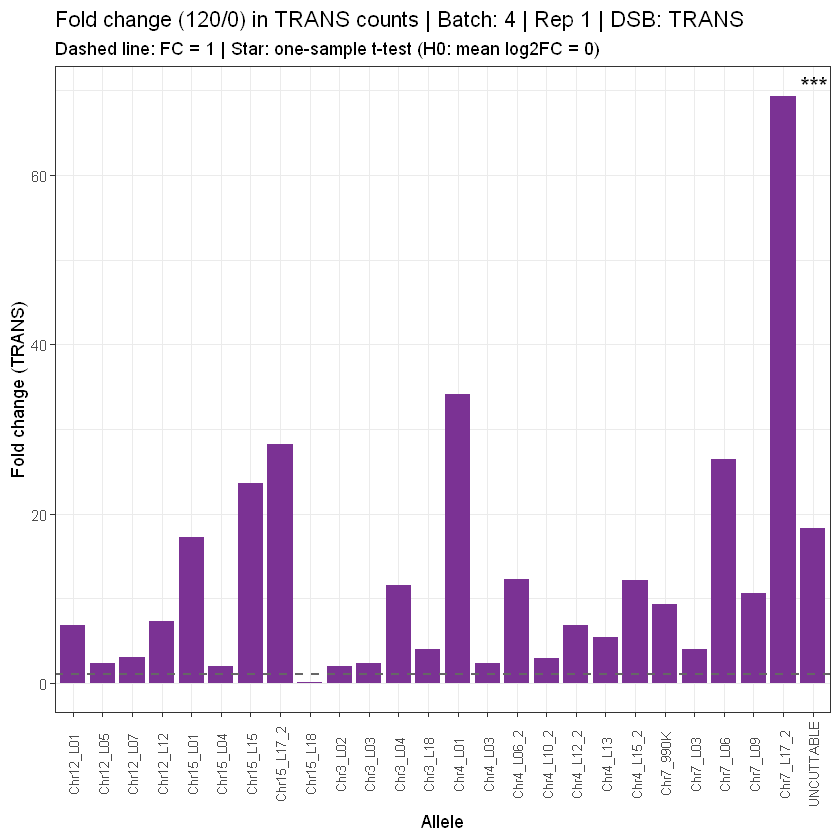

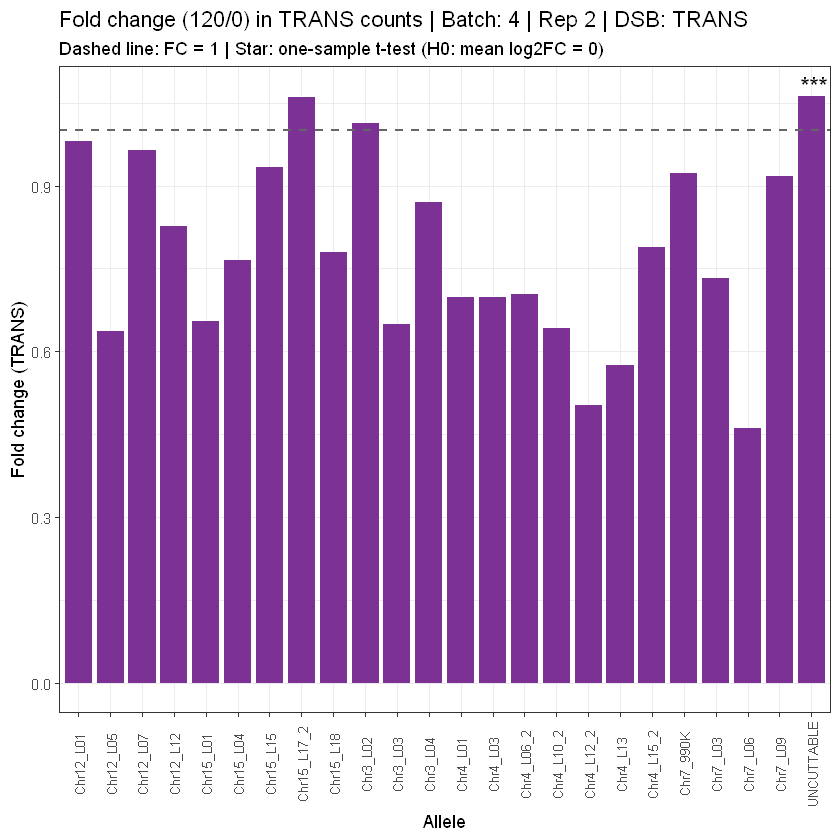

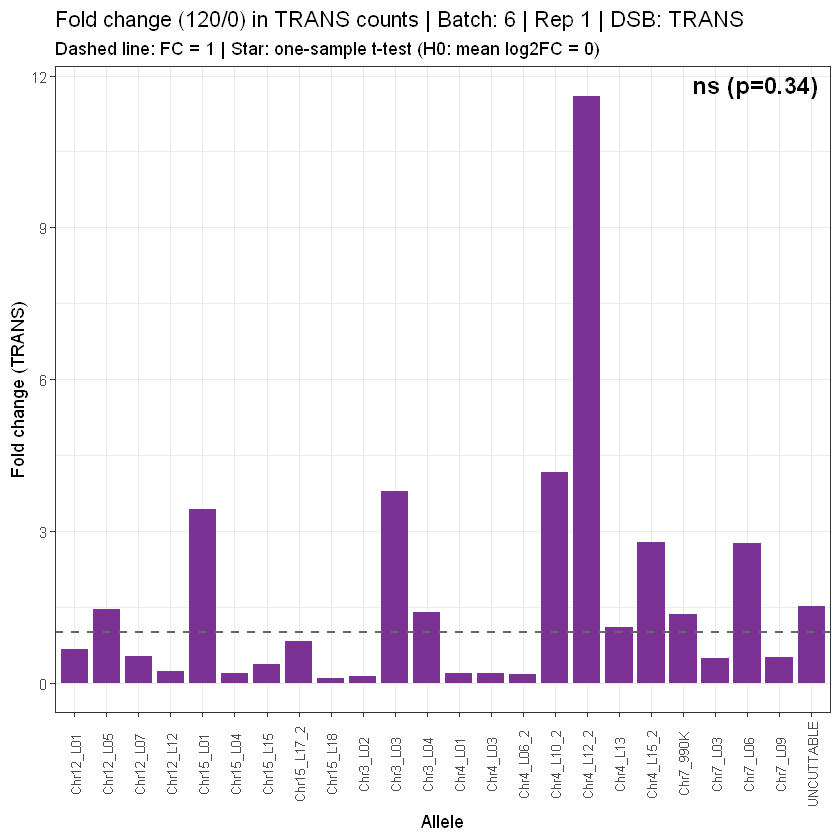

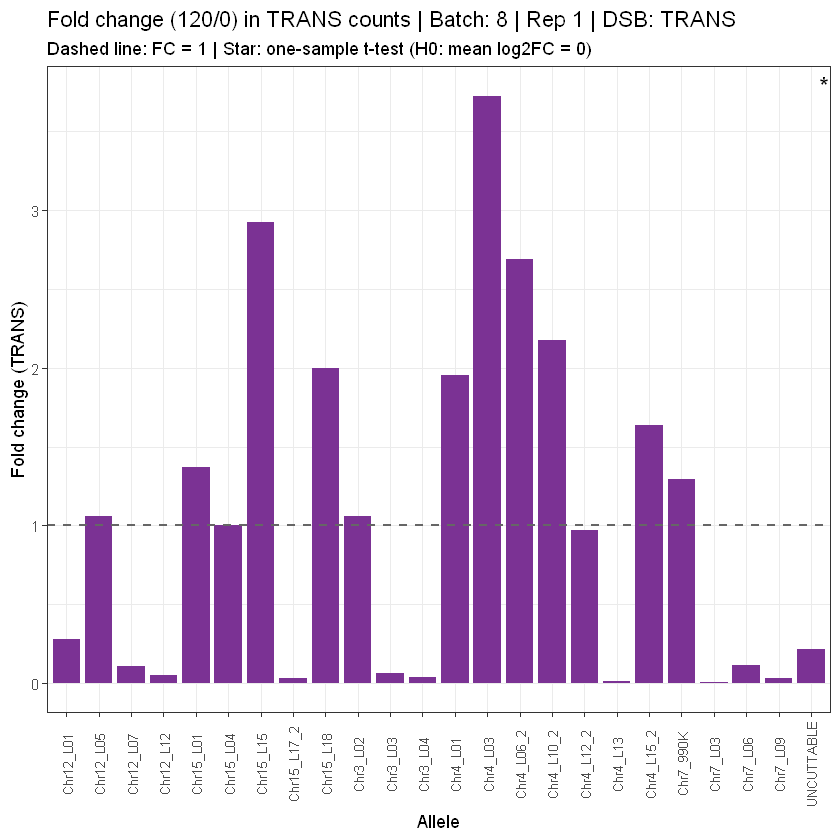

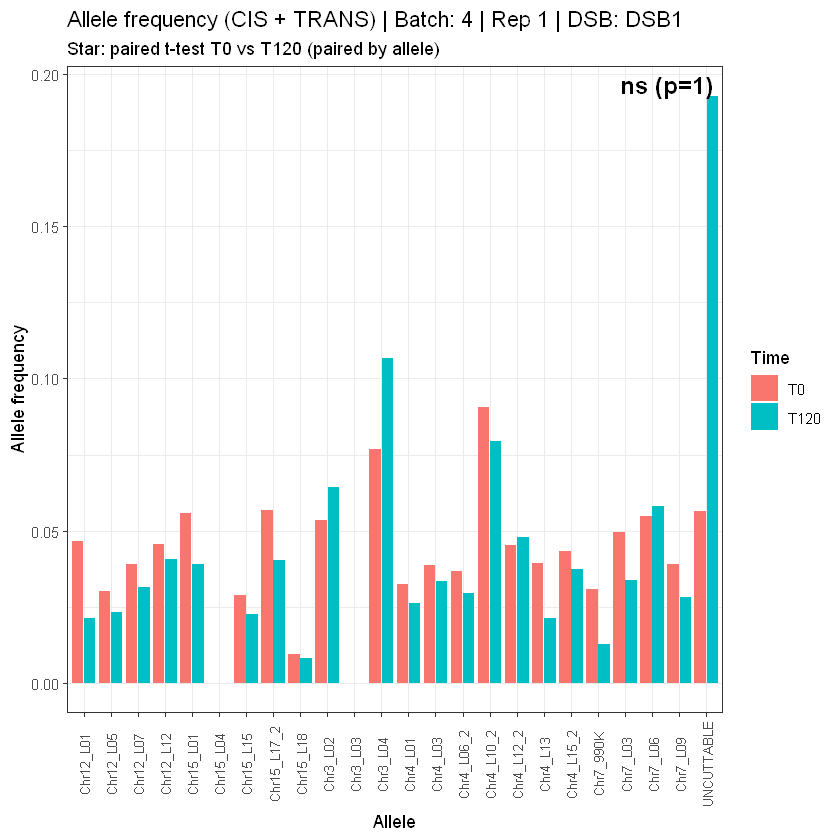

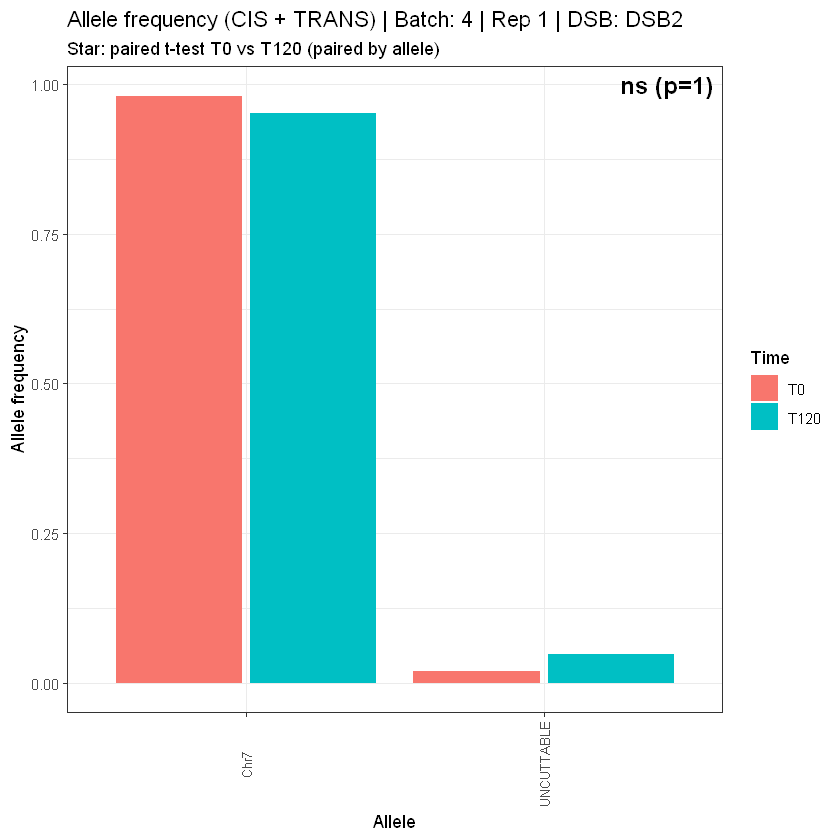

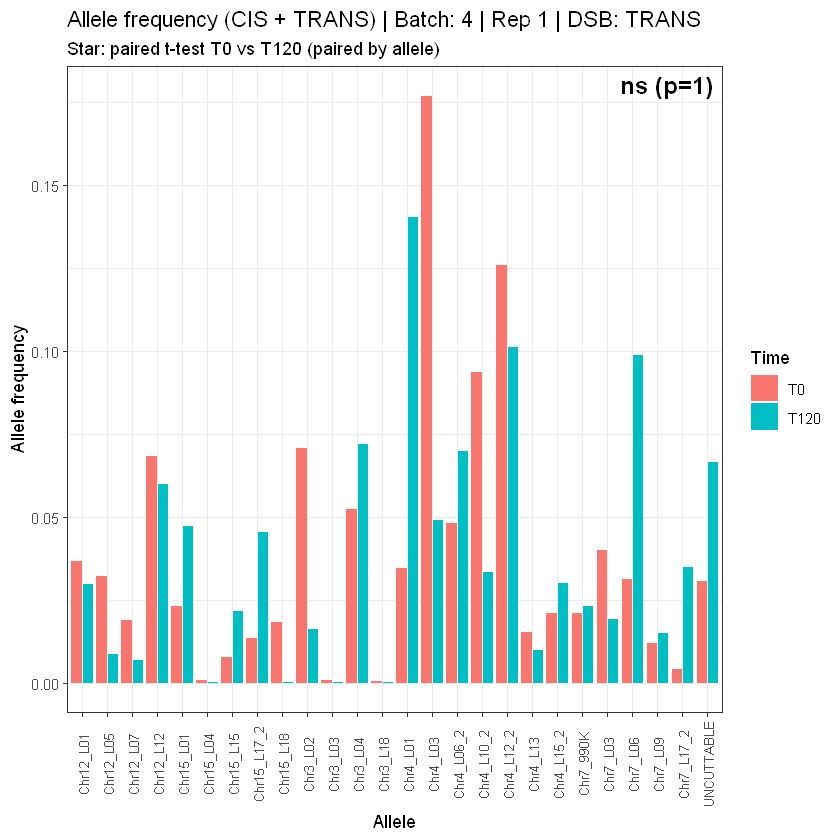

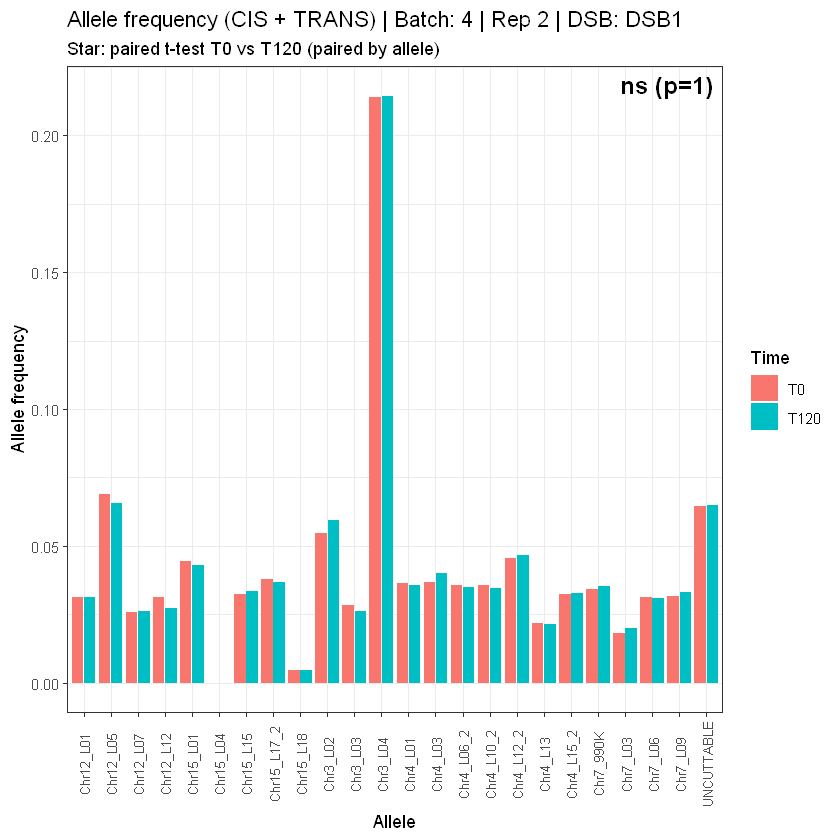

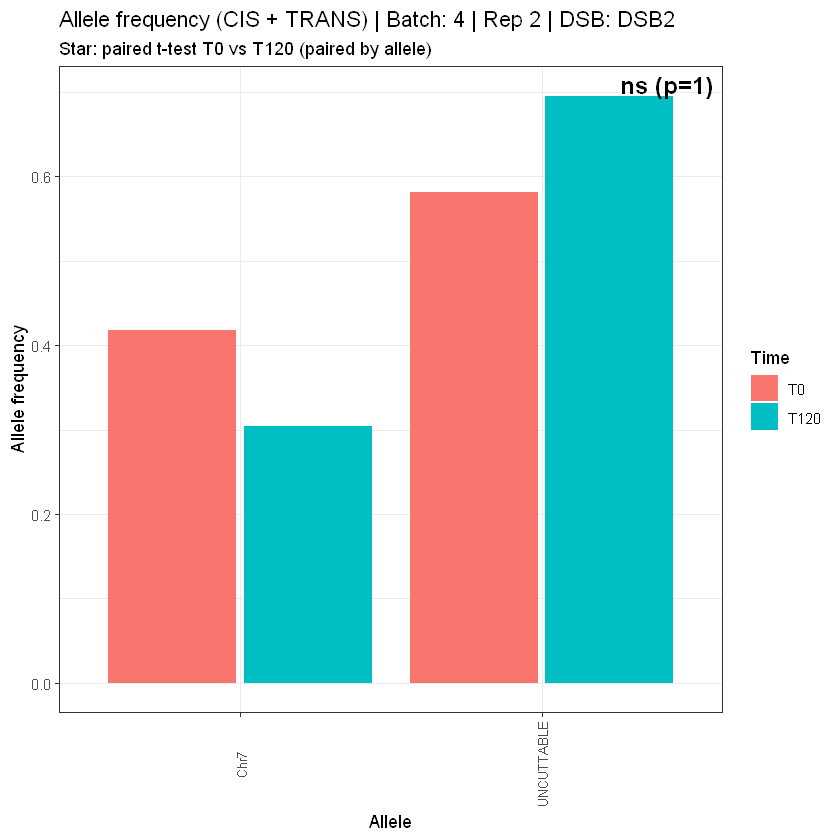

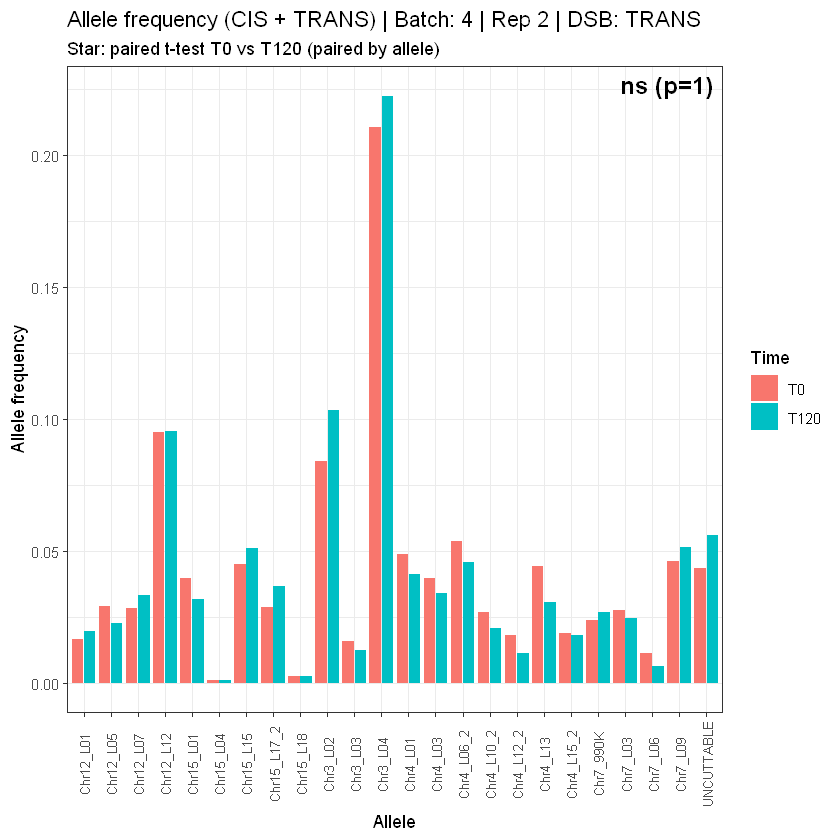

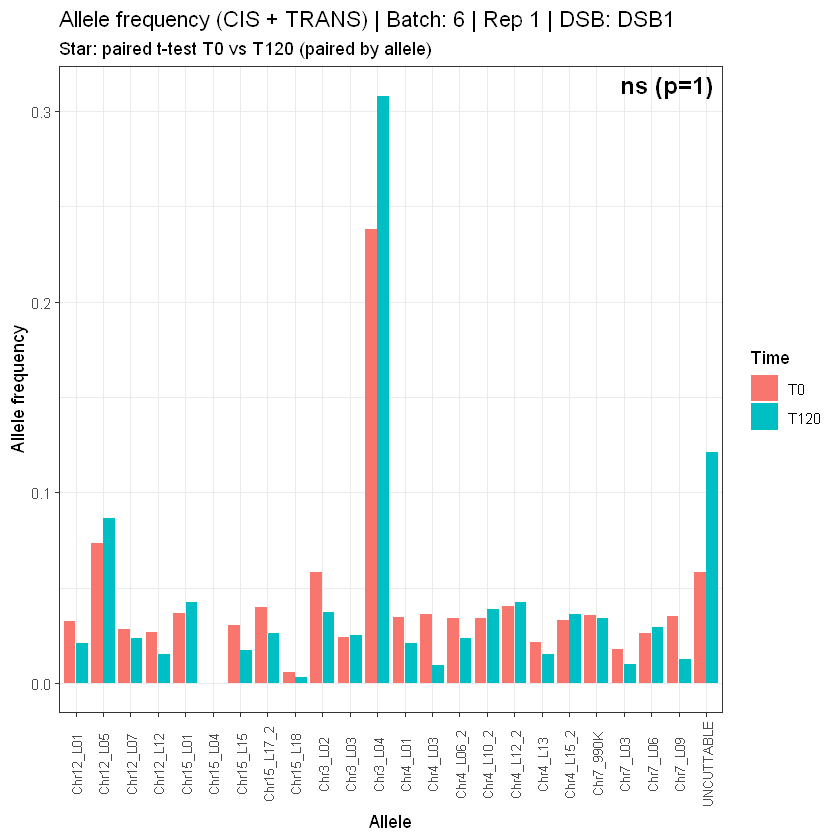

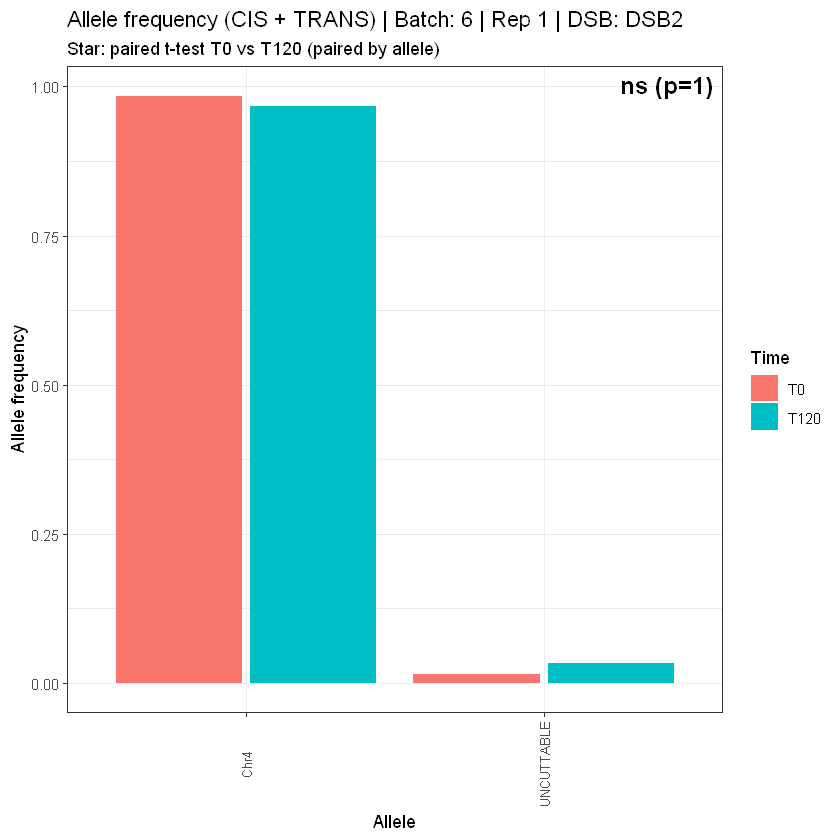

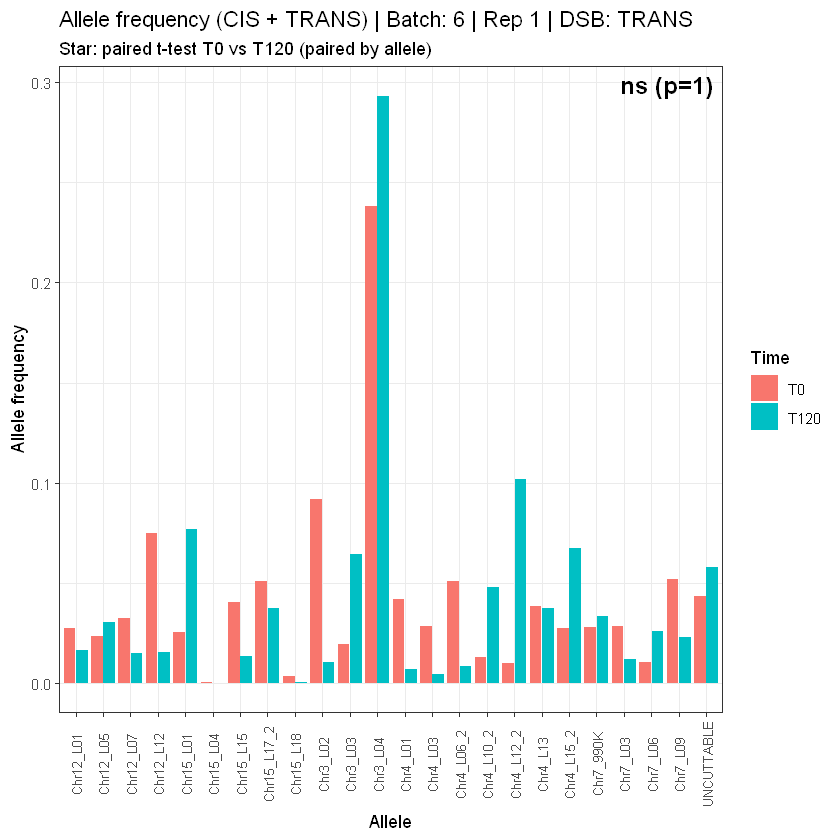

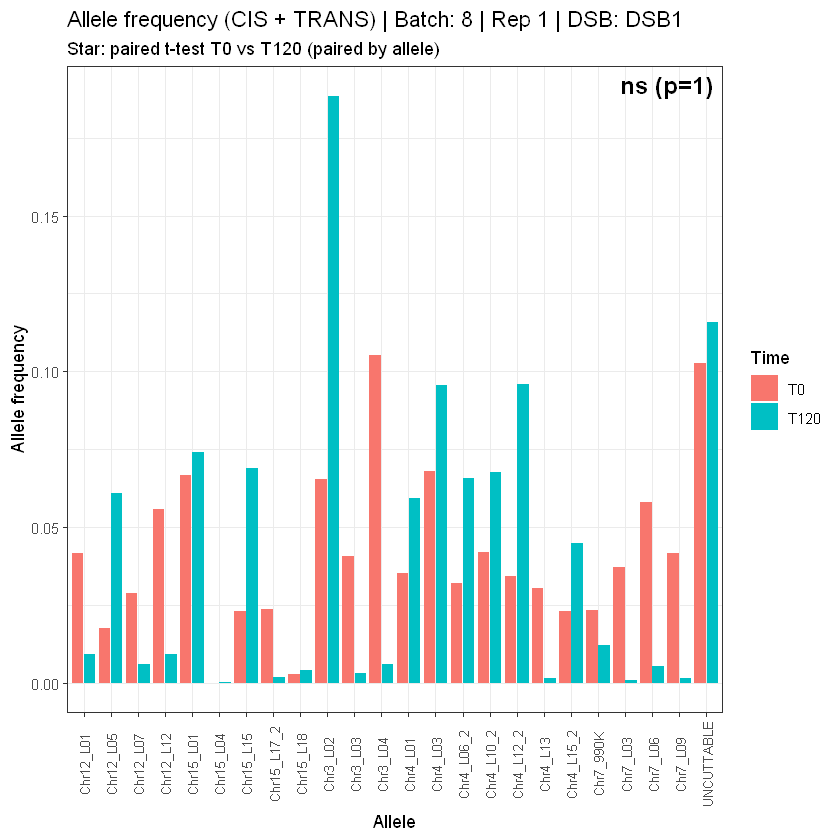

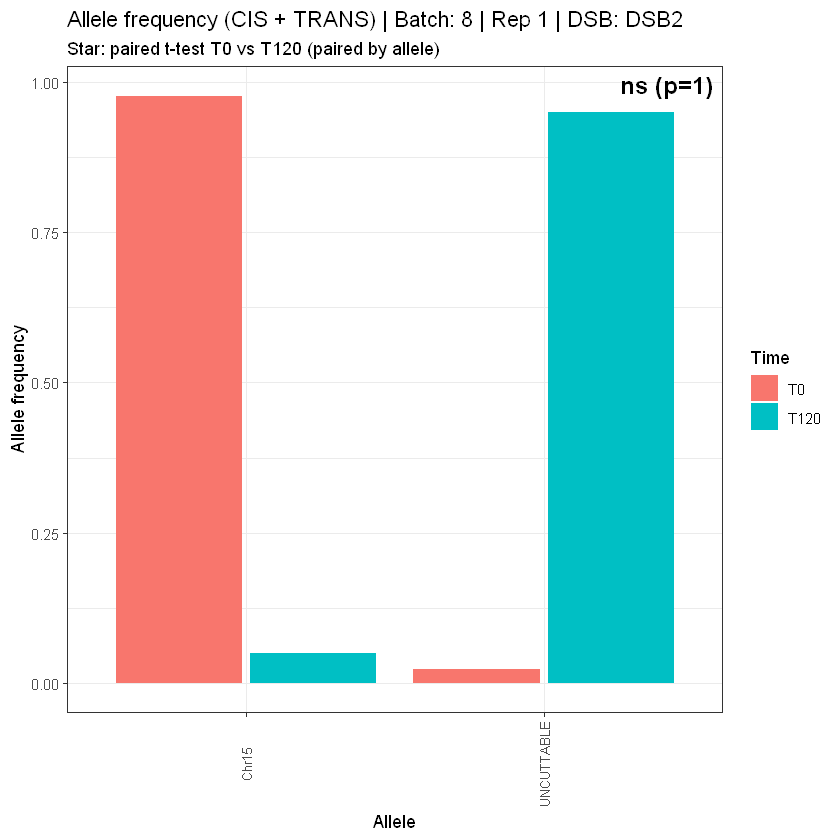

`geom_smooth()` using formula = 'y ~ x'


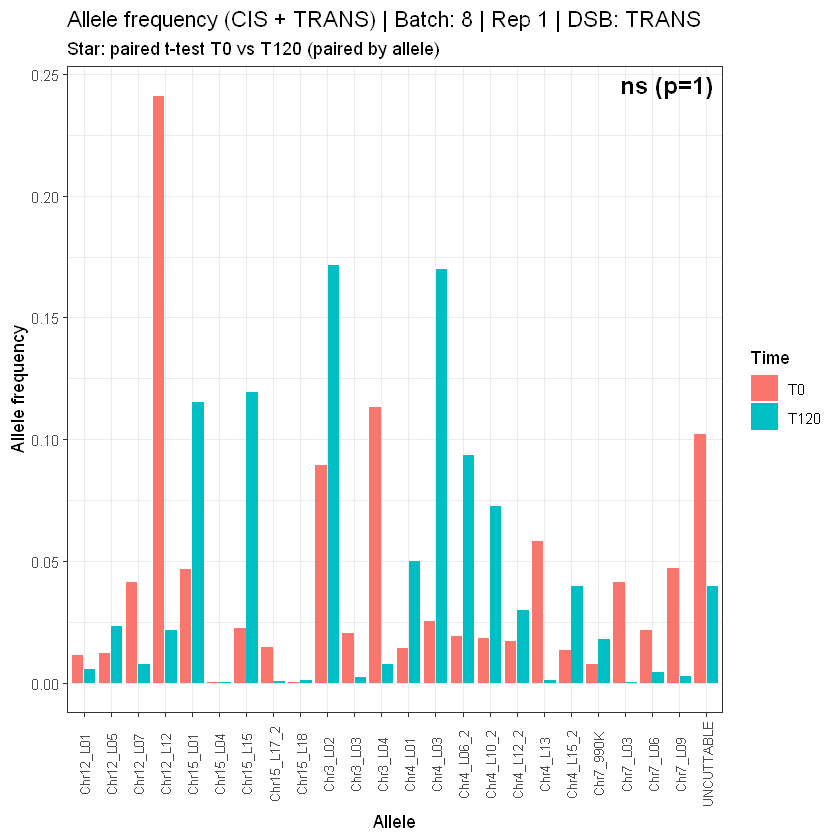

`geom_smooth()` using formula = 'y ~ x'


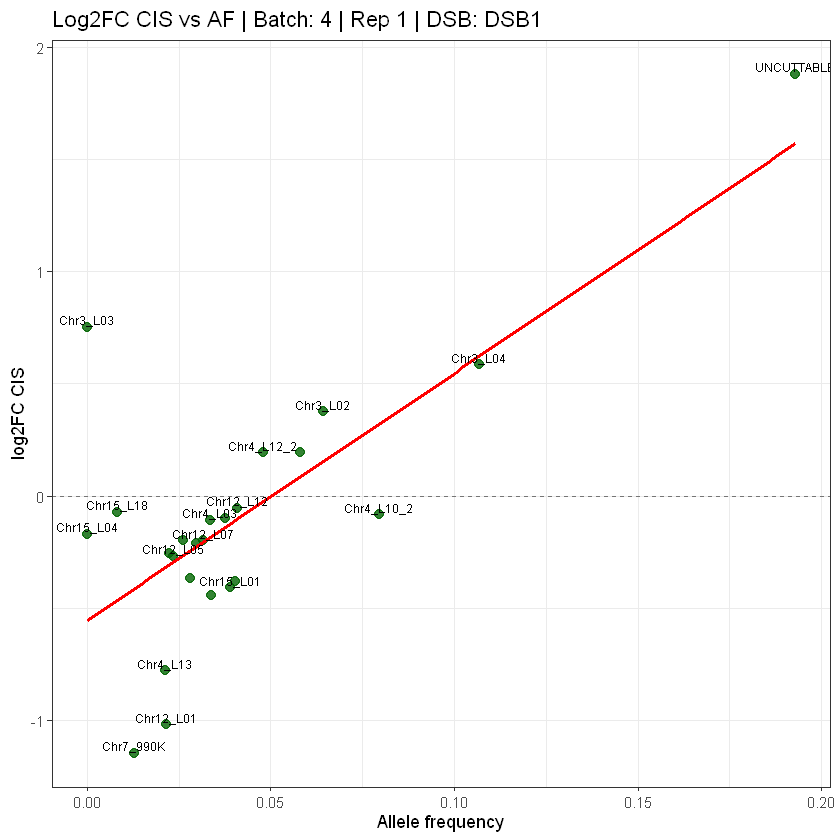

`geom_smooth()` using formula = 'y ~ x'


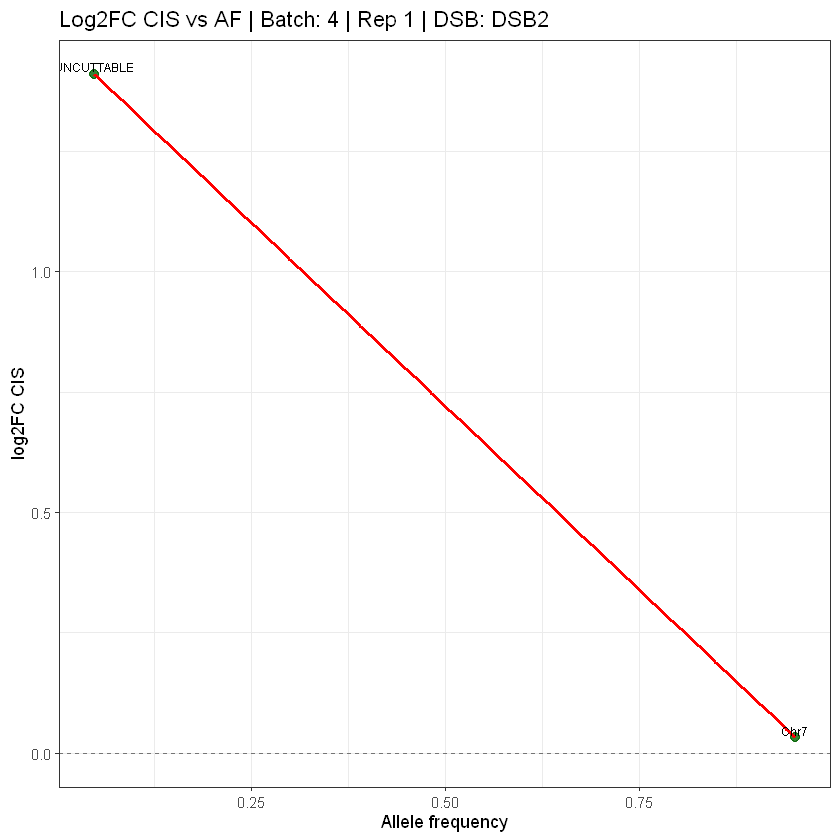

`geom_smooth()` using formula = 'y ~ x'


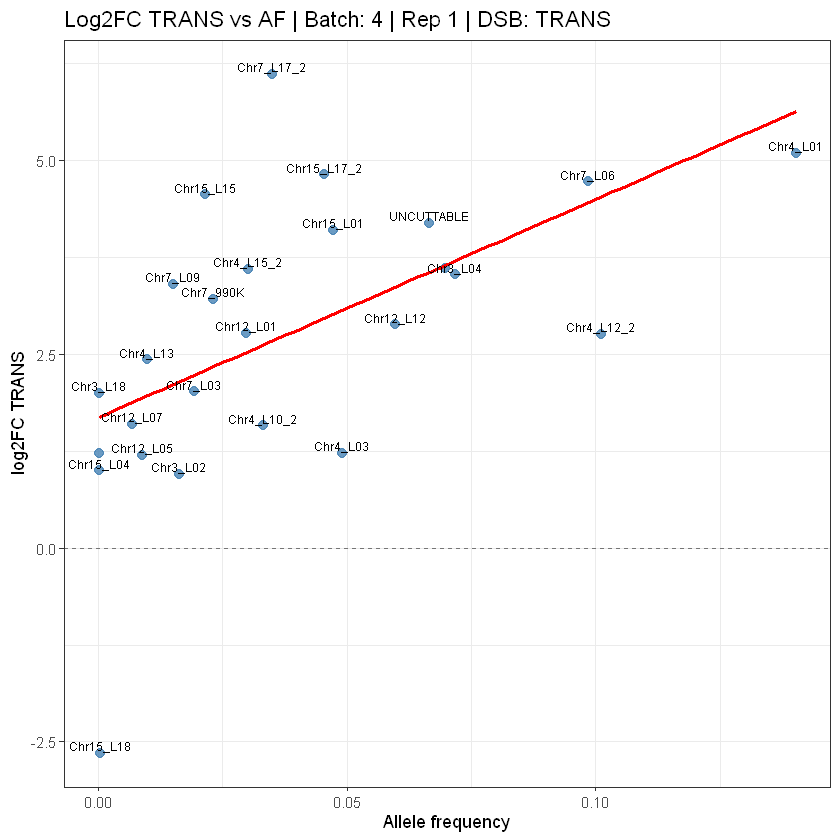

`geom_smooth()` using formula = 'y ~ x'


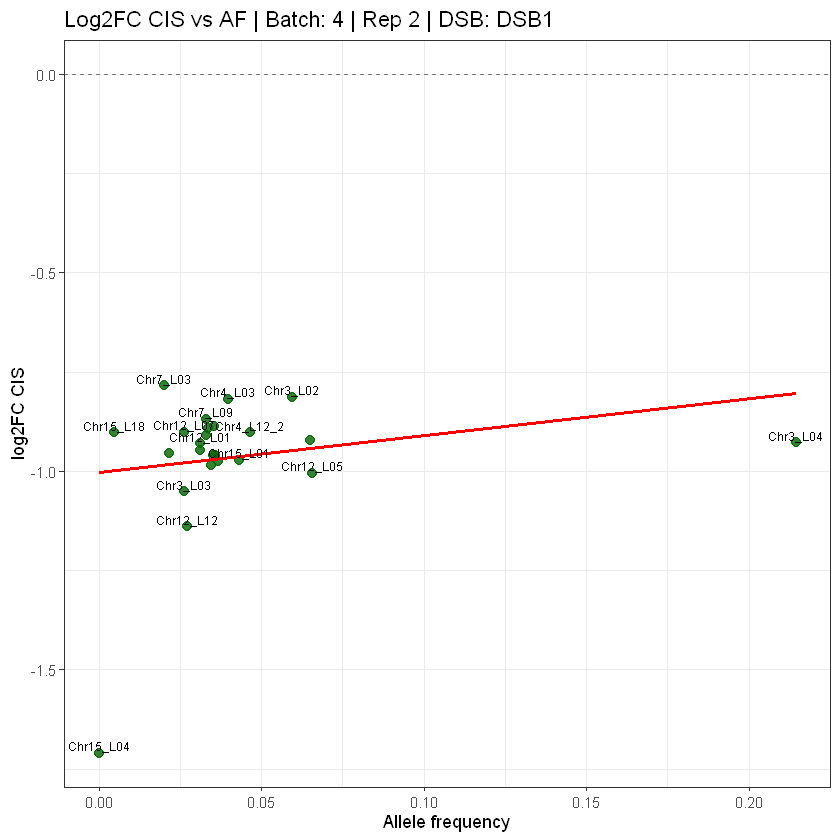

`geom_smooth()` using formula = 'y ~ x'


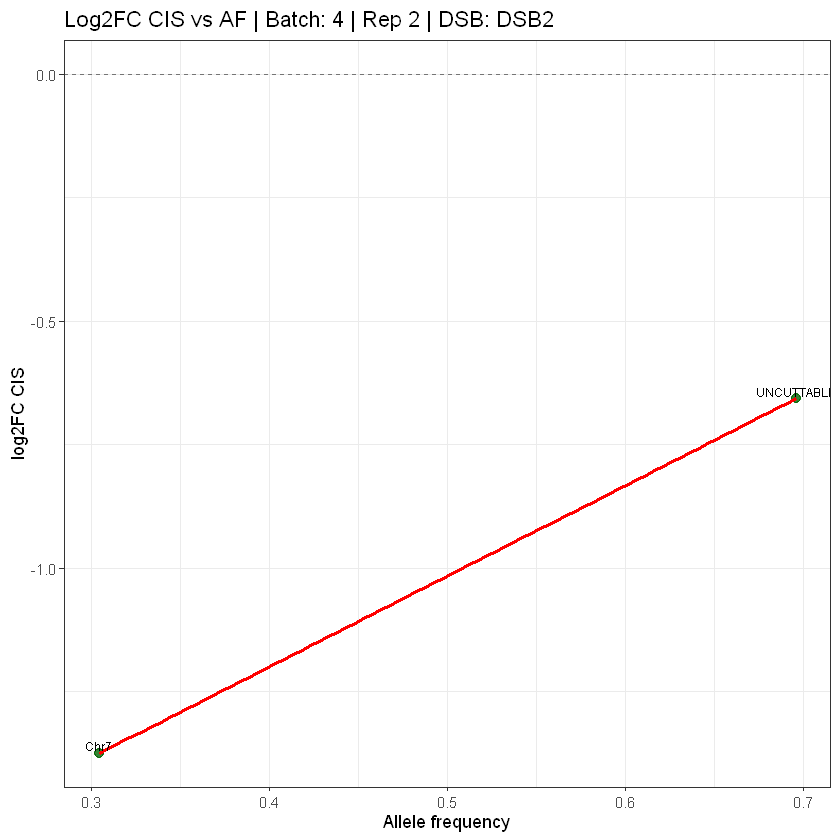

`geom_smooth()` using formula = 'y ~ x'


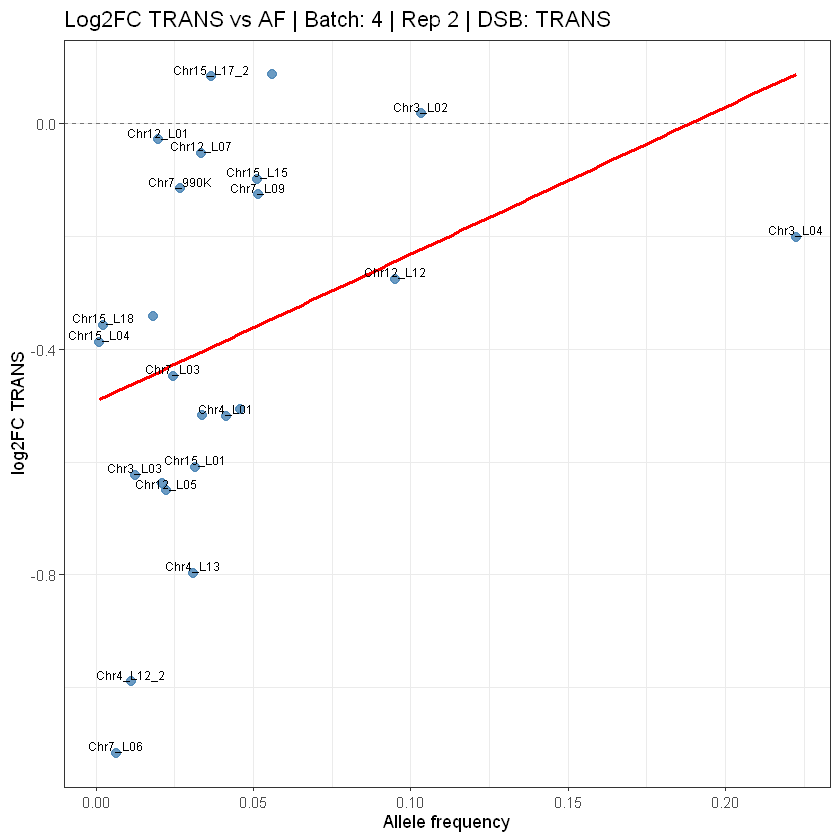

`geom_smooth()` using formula = 'y ~ x'


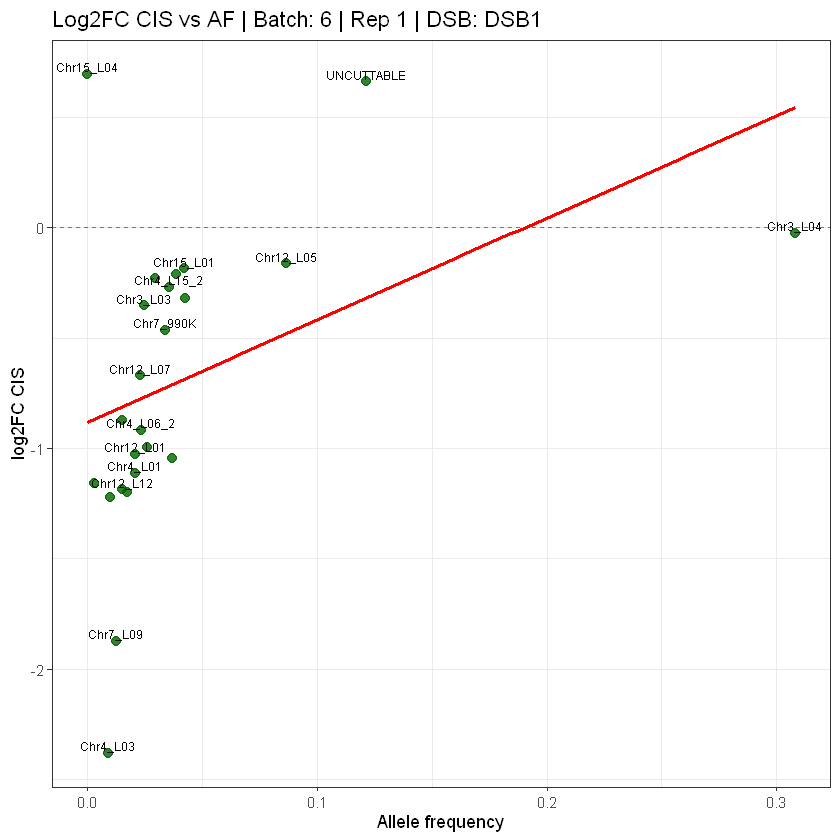

`geom_smooth()` using formula = 'y ~ x'


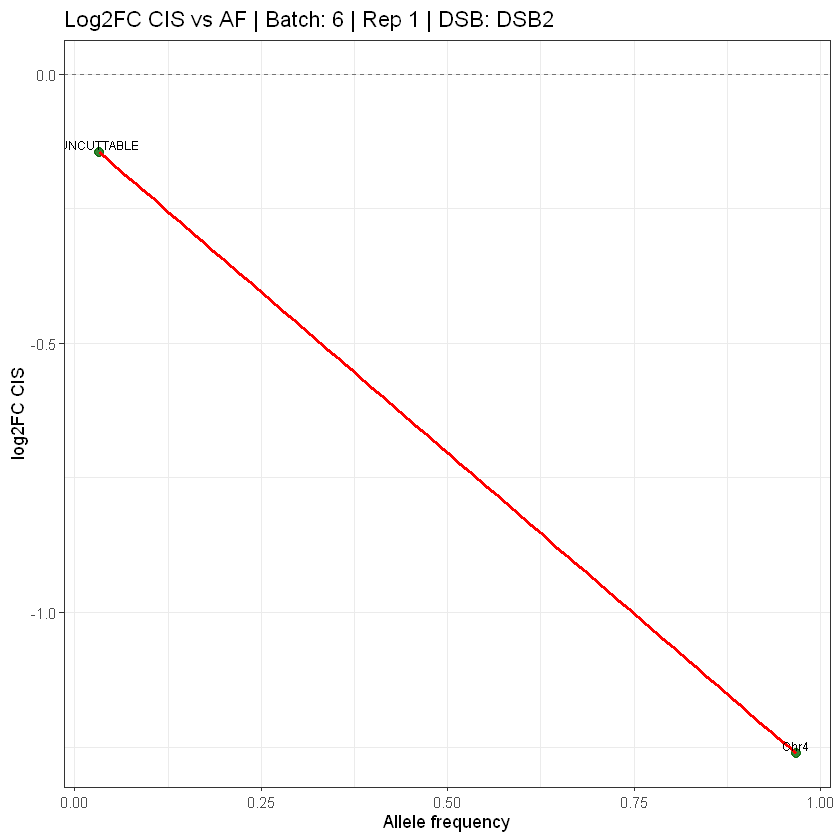

`geom_smooth()` using formula = 'y ~ x'


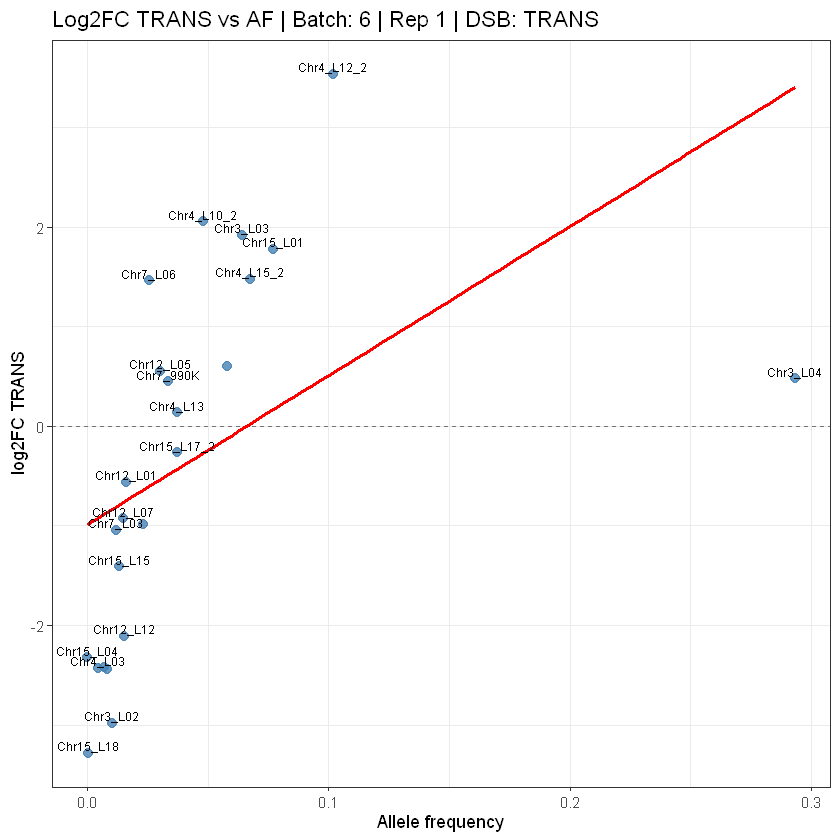

`geom_smooth()` using formula = 'y ~ x'


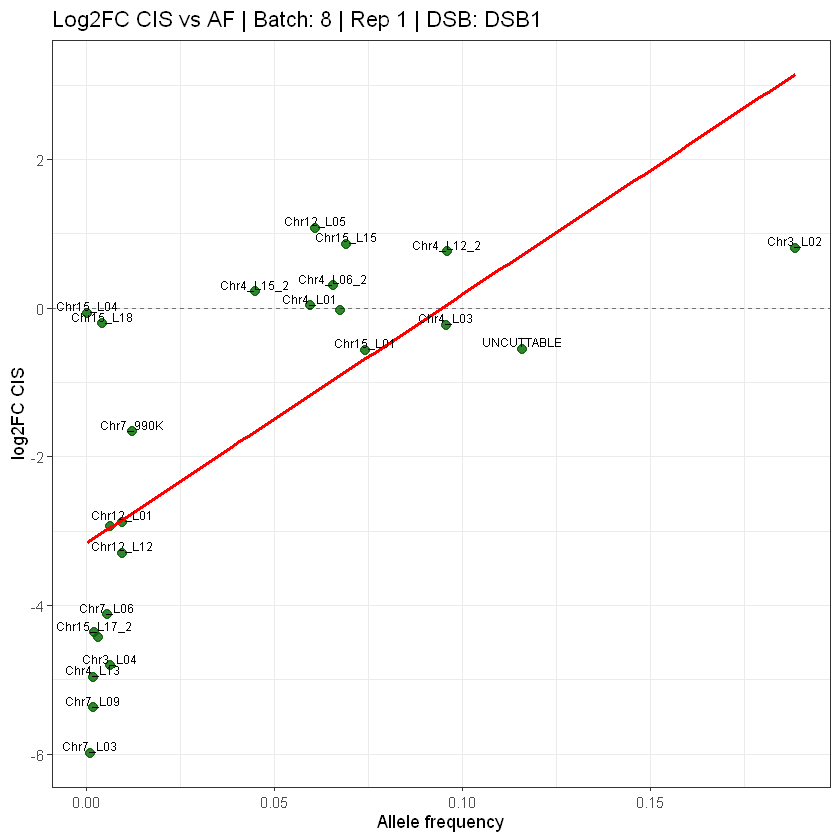

`geom_smooth()` using formula = 'y ~ x'


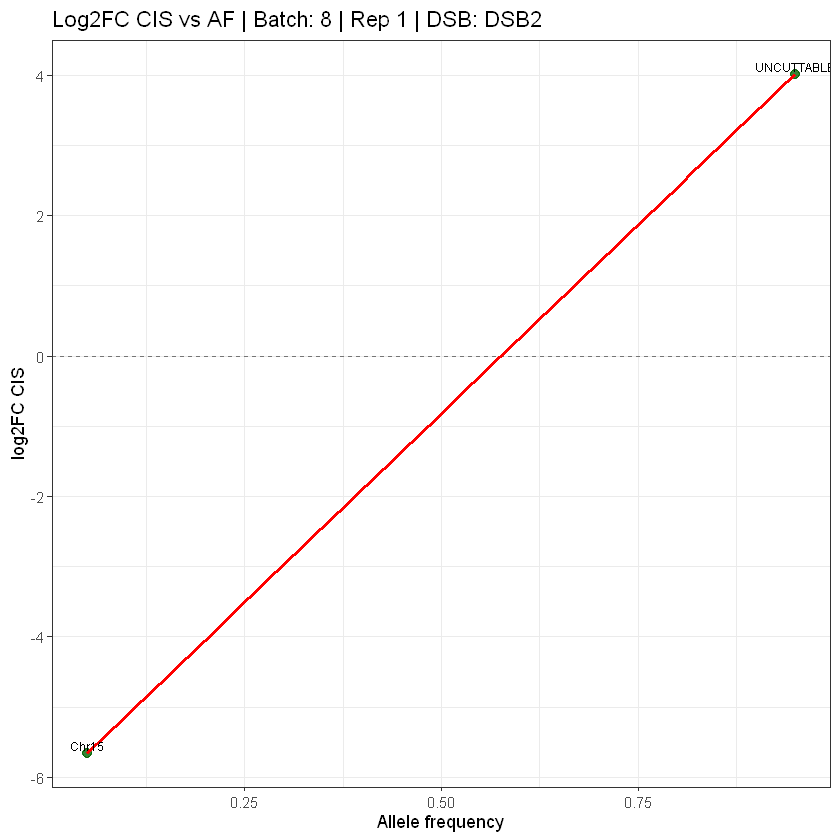

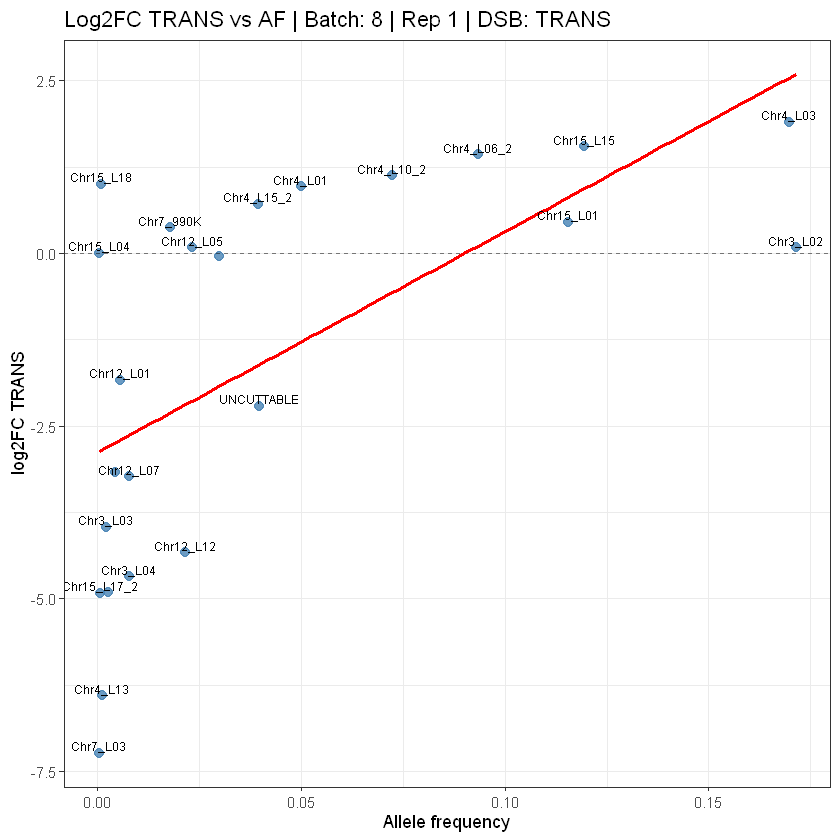

In [14]:
# ---- Sections 7, 8, 9: contribution bars, FC bars, and log2FC-vs-AF scatters (cleaned) ----
dsb_plot_levels <- function(x) {
  x <- unique(as.character(x))
  preferred <- c('DSB1', 'DSB2', 'TRANS')
  c(intersect(preferred, x), setdiff(sort(x), preferred))
}

plot_cis_contrib_by_batch <- function(df_cis_dist) {
  keys <- df_cis_dist %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_cis_dist %>%
      filter(batch == b, replicate == r, is.finite(Percent_Location_in_Cis))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      p <- ggplot(df_d, aes(x = allele, y = Percent_Location_in_Cis)) +
        geom_col(width = 0.85, na.rm = TRUE, fill = '#2c7fb8') +
        facet_wrap(~ time_point, scales = 'free_x') +
        coord_cartesian(ylim = c(0, 110)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('CIS% contribution by allele (within CIS only) | Batch: ', b, ' | ', r, ' | DSB: ', d),
          x = 'Allele', y = 'CIS% of CIS total'
        )
      print(p)
    }
  }
}

plot_trans_contrib_by_batch <- function(df_trans_dist) {
  keys <- df_trans_dist %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_trans_dist %>%
      filter(batch == b, replicate == r, is.finite(Percent_Location_in_Trans))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      p <- ggplot(df_d, aes(x = allele, y = Percent_Location_in_Trans)) +
        geom_col(width = 0.85, na.rm = TRUE, fill = '#7b3294') +
        facet_wrap(~ time_point, scales = 'free_x') +
        coord_cartesian(ylim = c(0, 110)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('TRANS% contribution by allele (within TRANS only) | Batch: ', b, ' | ', r, ' | DSB: ', d),
          x = 'Allele', y = 'TRANS% of TRANS total'
        )
      print(p)
    }
  }
}

plot_trans_percent_by_combo <- function(dat, combo_name) {
  df_plot <- dat %>%
    filter(combo == combo_name, time_point %in% c(0, 120)) %>%
    group_by(batch, replicate, time_point, DSB, allele) %>%
    summarise(Trans_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    group_by(batch, replicate, time_point, DSB) %>%
    mutate(
      Total_Trans = sum(Trans_Counts, na.rm = TRUE),
      Percent_Trans = if_else(Total_Trans > 0, 100 * Trans_Counts / Total_Trans, NA_real_)
    ) %>%
    ungroup() %>%
    filter(is.finite(Percent_Trans))

  if (nrow(df_plot) == 0) return(list())

  out <- list()
  for (d in dsb_plot_levels(df_plot$DSB)) {
    df_d <- df_plot %>% filter(DSB == d)
    if (nrow(df_d) == 0) next

    p <- ggplot(df_d, aes(x = allele, y = Percent_Trans, fill = factor(time_point, levels = c(0, 120), labels = c('T0', 'T120')))) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      facet_grid(batch + replicate ~ ., scales = 'free_x') +
      coord_cartesian(ylim = c(0, 110)) +
      theme_bw(base_size = 10) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 7)) +
      labs(
        title = paste('Percent of', combo_name, 'counts by allele (T0 vs T120) with replicate split | DSB:', d),
        x = 'Allele', y = '% within combo', fill = 'Time'
      )

    out[[d]] <- p
  }

  out
}

# Helper: make a significance label string
.make_sig_label <- function(sig, pval) {
  if (sig != 'ns') return(sig)
  if (is.na(pval)) return('ns')
  paste0('ns (p=', signif(pval, 2), ')')
}

plot_foldchange_cis_by_batch <- function(df_fc, ttest_fc = NULL) {
  keys <- df_fc %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_fc %>% filter(batch == b, replicate == r, is.finite(FoldChange_Cis_120_vs_0))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      p <- ggplot(df_d, aes(x = allele, y = FoldChange_Cis_120_vs_0)) +
        geom_col(width = 0.85, na.rm = TRUE, fill = '#008837') +
        geom_hline(yintercept = 1, linetype = 'dashed', color = 'grey40', linewidth = 0.7) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title    = paste0('Fold change (120/0) in CIS counts | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = 'Dashed line: FC = 1 | Star: one-sample t-test (H0: mean log2FC = 0)',
          x = 'Allele', y = 'Fold change (CIS)'
        )

      if (!is.null(ttest_fc)) {
        ann <- ttest_fc %>% filter(batch == b, replicate == r, DSB == d)
        if (nrow(ann) > 0) {
          lbl <- .make_sig_label(ann$significance[[1]], ann$p_value[[1]])
          p <- p + annotate('text', x = Inf, y = Inf, label = lbl,
                            hjust = 1.1, vjust = 1.5, size = 5, fontface = 'bold')
        }
      }
      print(p)
    }
  }
}

plot_foldchange_trans_by_batch <- function(df_fc, ttest_fc = NULL) {
  keys <- df_fc %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_fc %>% filter(batch == b, replicate == r, is.finite(FoldChange_Trans_120_vs_0))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      p <- ggplot(df_d, aes(x = allele, y = FoldChange_Trans_120_vs_0)) +
        geom_col(width = 0.85, na.rm = TRUE, fill = '#7b3294') +
        geom_hline(yintercept = 1, linetype = 'dashed', color = 'grey40', linewidth = 0.7) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title    = paste0('Fold change (120/0) in TRANS counts | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = 'Dashed line: FC = 1 | Star: one-sample t-test (H0: mean log2FC = 0)',
          x = 'Allele', y = 'Fold change (TRANS)'
        )

      if (!is.null(ttest_fc)) {
        ann <- ttest_fc %>% filter(batch == b, replicate == r, DSB == d)
        if (nrow(ann) > 0) {
          lbl <- .make_sig_label(ann$significance[[1]], ann$p_value[[1]])
          p <- p + annotate('text', x = Inf, y = Inf, label = lbl,
                            hjust = 1.1, vjust = 1.5, size = 5, fontface = 'bold')
        }
      }
      print(p)
    }
  }
}

plot_allele_frequency_by_batch <- function(df_af, ttest_af = NULL) {
  keys <- df_af %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_af %>% filter(batch == b, replicate == r, is.finite(Allele_Frequency))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      p <- ggplot(df_d, aes(x = allele, y = Allele_Frequency, fill = factor(time_point, levels = c(0, 120), labels = c('T0', 'T120')))) +
        geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title    = paste0('Allele frequency (CIS + TRANS) | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = 'Star: paired t-test T0 vs T120 (paired by allele)',
          x = 'Allele', y = 'Allele frequency', fill = 'Time'
        )

      if (!is.null(ttest_af)) {
        ann <- ttest_af %>% filter(batch == b, replicate == r, DSB == d)
        if (nrow(ann) > 0) {
          lbl <- .make_sig_label(ann$significance[[1]], ann$p_value[[1]])
          p <- p + annotate('text', x = Inf, y = Inf, label = lbl,
                            hjust = 1.1, vjust = 1.5, size = 5, fontface = 'bold')
        }
      }
      print(p)
    }
  }
}

plot_correlation_cis <- function(df, batch_name, replicate_name, dsb_name) {
  df_plot <- df %>%
    filter(batch == batch_name, replicate == replicate_name, DSB == dsb_name) %>%
    mutate(valid = is.finite(Allele_Frequency) & is.finite(log2FC_CIS)) %>%
    filter(valid)

  if (nrow(df_plot) < 2) return(NULL)

  p <- ggplot(df_plot, aes(x = Allele_Frequency, y = log2FC_CIS)) +
    geom_point(size = 2.4, alpha = 0.8, color = 'darkgreen') +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_smooth(aes(x = Allele_Frequency, y = log2FC_CIS), method = 'lm', se = FALSE, color = 'red', inherit.aes = FALSE) +
    theme_bw(base_size = 11) +
    labs(title = paste0('Log2FC CIS vs AF | Batch: ', batch_name, ' | ', replicate_name, ' | DSB: ', dsb_name), x = 'Allele frequency', y = 'log2FC CIS')

  if (has_ggrepel) {
    p <- p + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
  } else {
    p <- p + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
  }
  p
}

plot_correlation_trans <- function(df, batch_name, replicate_name, dsb_name) {
  df_plot <- df %>%
    filter(batch == batch_name, replicate == replicate_name, DSB == dsb_name) %>%
    mutate(valid = is.finite(Allele_Frequency) & is.finite(log2FC_TRANS)) %>%
    filter(valid)

  if (nrow(df_plot) < 2) return(NULL)

  p <- ggplot(df_plot, aes(x = Allele_Frequency, y = log2FC_TRANS)) +
    geom_point(size = 2.4, alpha = 0.8, color = 'steelblue') +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_smooth(aes(x = Allele_Frequency, y = log2FC_TRANS), method = 'lm', se = FALSE, color = 'red', inherit.aes = FALSE) +
    theme_bw(base_size = 11) +
    labs(title = paste0('Log2FC TRANS vs AF | Batch: ', batch_name, ' | ', replicate_name, ' | DSB: ', dsb_name), x = 'Allele frequency', y = 'log2FC TRANS')

  if (has_ggrepel) {
    p <- p + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
  } else {
    p <- p + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
  }
  p
}

# Run section 7 plots

df_cis_dist <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Percent_Location_in_Cis)

df_trans_dist <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Percent_Location_in_Trans)

plot_cis_contrib_by_batch(df_cis_dist)
plot_trans_contrib_by_batch(df_trans_dist)

p_trans_ad_list <- plot_trans_percent_by_combo(dat_focus, 'A_to_D')
if (length(p_trans_ad_list) > 0) purrr::walk(p_trans_ad_list, print)

p_trans_cb_list <- plot_trans_percent_by_combo(dat_focus, 'C_to_B')
if (length(p_trans_cb_list) > 0) purrr::walk(p_trans_cb_list, print)

# Backward-compatible single objects for downstream references
p_trans_ad <- if (length(p_trans_ad_list) > 0) p_trans_ad_list[[1]] else NULL
p_trans_cb <- if (length(p_trans_cb_list) > 0) p_trans_cb_list[[1]] else NULL

# Run section 8 plots — pass t-test tables for significance annotations
plot_foldchange_cis_by_batch(dat_fc_cis,   ttest_fc = ttest_log2fc_cis)
plot_foldchange_trans_by_batch(dat_fc_trans, ttest_fc = ttest_log2fc_trans)
plot_allele_frequency_by_batch(dat_allele_freq, ttest_af = ttest_af_t0_t120)

# Run section 9 plots
plot_keys <- dat_fc_af %>% distinct(batch, replicate, DSB) %>% arrange(batch, replicate, DSB)

for (i in seq_len(nrow(plot_keys))) {
  b <- plot_keys$batch[[i]]
  r <- plot_keys$replicate[[i]]
  d <- plot_keys$DSB[[i]]
  p_cis_scatter <- plot_correlation_cis(dat_fc_af, b, r, d)
  p_trans_scatter <- plot_correlation_trans(dat_fc_af, b, r, d)
  if (!is.null(p_cis_scatter)) print(p_cis_scatter)
  if (!is.null(p_trans_scatter)) print(p_trans_scatter)
}


**Figure set (Sections 7–9). Allele contribution, fold-change bars, and log2FC-vs-AF diagnostics.**

- **Methods/Computation:** Per-allele contribution bars report normalized channel fractions, and abundance-shift diagnostics model trend lines via linear fit $\hat{y}=\beta_0+\beta_1 x$ with $x=\mathrm{AF}$ and $y=\log_2\mathrm{FC}$.
- **Biological relevance (with sources):** A strong positive $\beta_1$ implies abundance-linked shifts, while weak slope with outlier loci supports selective, structure-dependent partner-choice effects in damaged nuclei [1,2,7].

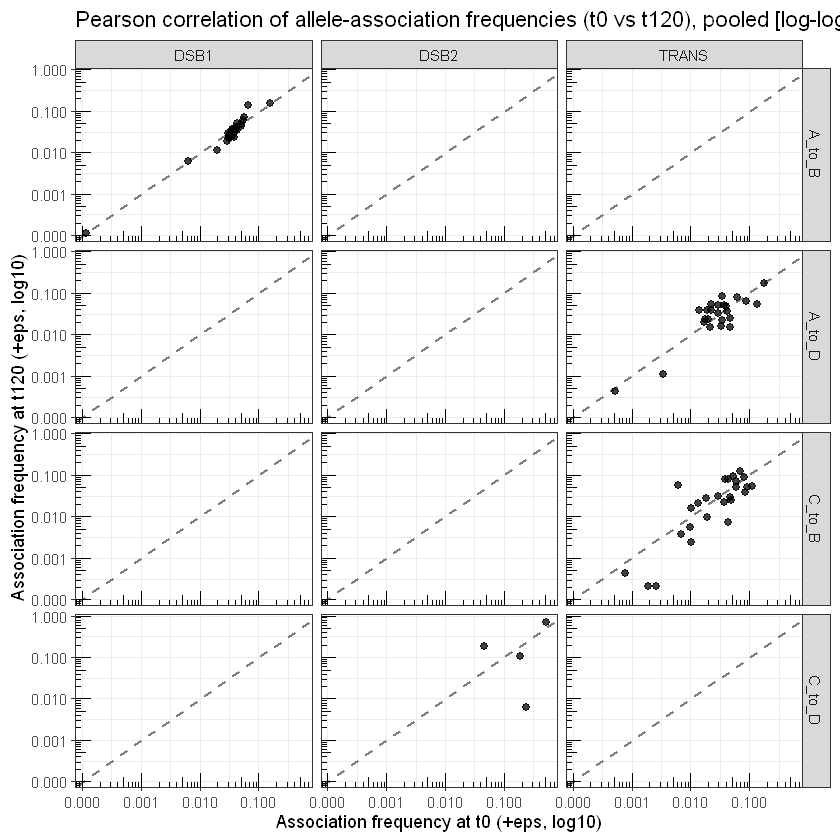

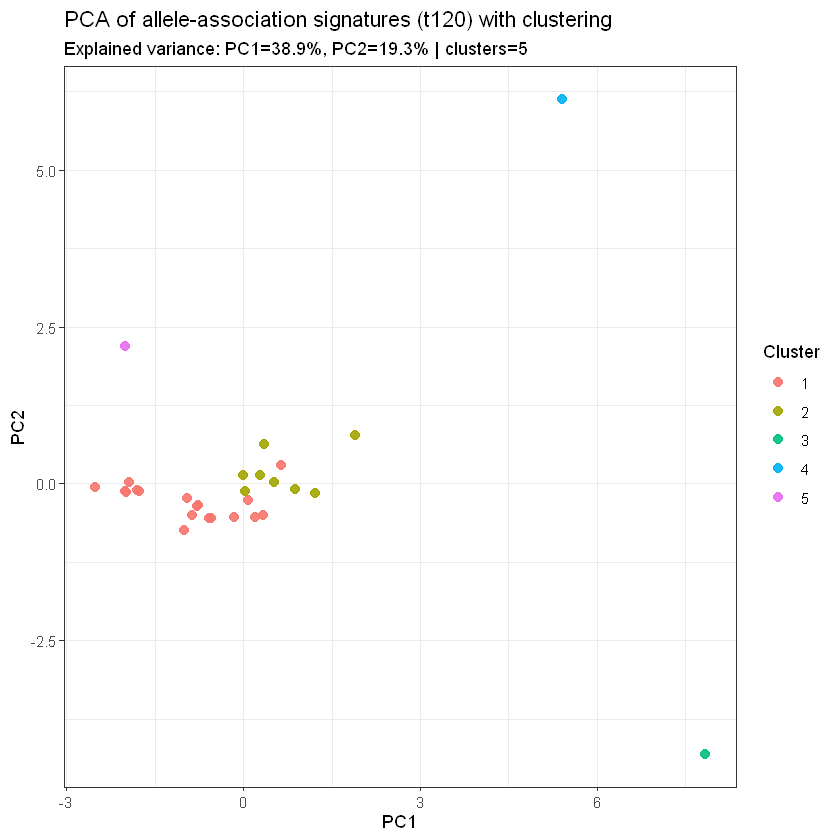

Exporting 13 plots: 3C_QC_total_counts, 3C_group4_trans_share, 3C_group4_cis_share, 3C_group4_within_cis, 3C_group4_within_trans, 3C_af_corr_pooled_t0_t120, 3C_af_corr_pooled_t0_t120_loglog, 3C_pca_allele_signatures, 3C_allele_association_heatmap, 3C_trans_combo_A_to_D, 3C_trans_combo_C_to_B, 3C_trans_combo_A_to_D_TRANS, 3C_trans_combo_C_to_B_TRANS

Saved advanced plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



object,n_rows
<chr>,<int>
dat_raw,596
dat_focus,596
dat_norm_combo,404
dat_group4,8
dat_allele_freq,404
dat_fc_cis,202
dat_fc_trans,202
dat_fc_af,202
cor_summary,12


PCA cluster sizes:



  cluster n_alleles
1       1        18
2       2         8
3       3         1
4       4         1
5       5         1


Detected TAD-like domains (top 15 rows):



# A tibble: 15 × 2
   allele     tad_like_domain
   <chr>      <chr>          
 1 UNCUTTABLE Domain_3       
 2 Chr7       Domain_4       
 3 Chr4       Domain_5       
 4 Chr3_L04   Domain_2       
 5 Chr3_L02   Domain_1       
 6 Chr4_L03   Domain_1       
 7 Chr15_L15  Domain_1       
 8 Chr4_L06_2 Domain_1       
 9 Chr4_L12_2 Domain_1       
10 Chr12_L05  Domain_1       
11 Chr15_L01  Domain_1       
12 Chr4_L10_2 Domain_1       
13 Chr4_L15_2 Domain_1       
14 Chr4_L01   Domain_1       
15 Chr7_L06   Domain_1       


metric,na_fraction
<chr>,<dbl>
Log2FC_Cis_120_vs_0,0.4851485
Log2FC_Trans_120_vs_0,0.5148515
dat_fc_af$log2FC_CIS,0.4851485
dat_fc_af$log2FC_TRANS,0.5148515
dat_fc_af$Allele_Frequency,0.0000000


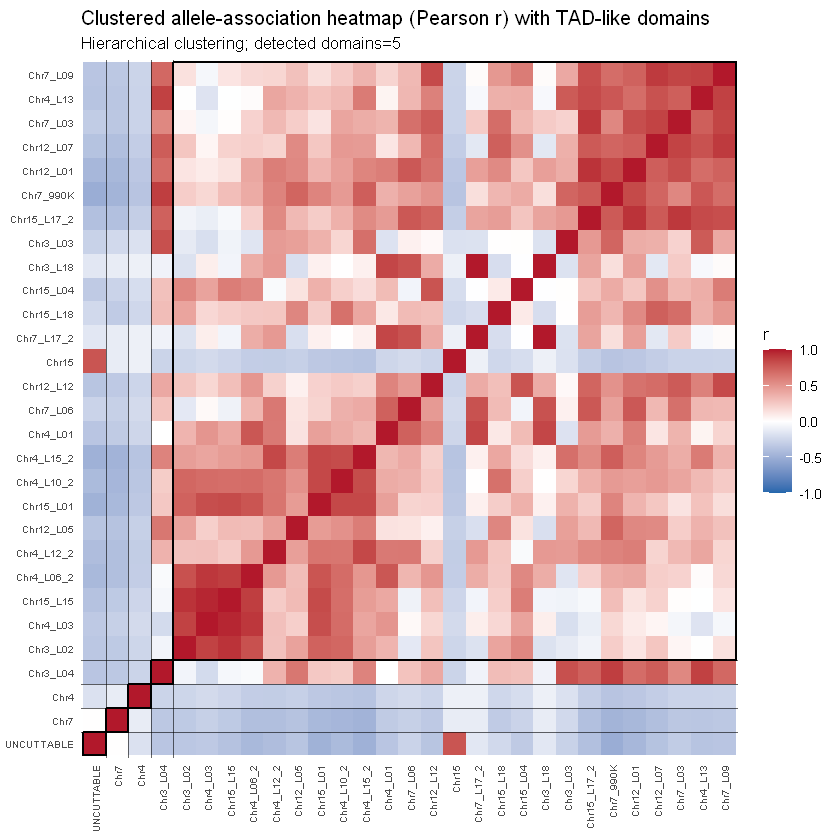

: 

In [ ]:
# ---- Advanced export + diagnostics ----
out_dir <- file.path(getwd(), 'Outputs', '3C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# Export t-test result tables if available
if (exists('ttest_trans_t0_t120') && is.data.frame(ttest_trans_t0_t120) && nrow(ttest_trans_t0_t120) > 0) {
  readr::write_csv(ttest_trans_t0_t120, file.path(out_dir, '3C_ttest_trans_t0_vs_t120.csv'))
}
if (exists('ttest_cis_t0_t120') && is.data.frame(ttest_cis_t0_t120) && nrow(ttest_cis_t0_t120) > 0) {
  readr::write_csv(ttest_cis_t0_t120, file.path(out_dir, '3C_ttest_cis_t0_vs_t120.csv'))
}
if (exists('ttest_af_t0_t120') && is.data.frame(ttest_af_t0_t120) && nrow(ttest_af_t0_t120) > 0) {
  readr::write_csv(ttest_af_t0_t120, file.path(out_dir, '3C_ttest_af_t0_vs_t120.csv'))
}
if (exists('ttest_log2fc_cis') && is.data.frame(ttest_log2fc_cis) && nrow(ttest_log2fc_cis) > 0) {
  readr::write_csv(ttest_log2fc_cis, file.path(out_dir, '3C_ttest_log2fc_cis.csv'))
}
if (exists('ttest_log2fc_trans') && is.data.frame(ttest_log2fc_trans) && nrow(ttest_log2fc_trans) > 0) {
  readr::write_csv(ttest_log2fc_trans, file.path(out_dir, '3C_ttest_log2fc_trans.csv'))
}

# --- Added visuals requested: log-axis AF correlation, PCA clustering, and clustered allele heatmap ---
eps_log <- 1e-6
p_overall_af_corr_loglog <- NULL
p_pca_allele_signatures <- NULL
p_allele_association_heatmap <- NULL
tad_like_domains <- tibble::tibble()
pca_cluster_summary <- tibble::tibble()

choose_k_fixed <- function(n, k_default = 4L) {
  n <- as.integer(n)
  if (is.na(n) || n < 3L) return(2L)
  k <- max(2L, min(as.integer(k_default), n - 1L))
  as.integer(k)
}

# 1) Pooled AF correlation on log-log axes
if (exists('dat_wide_overall') && is.data.frame(dat_wide_overall) && nrow(dat_wide_overall) > 0 &&
    all(c('t0', 't120') %in% names(dat_wide_overall))) {
  df_log <- dat_wide_overall %>%
    dplyr::filter(is.finite(t0), is.finite(t120), t0 >= 0, t120 >= 0)

  if (nrow(df_log) >= 3) {
    p_overall_af_corr_loglog <- ggplot(df_log, aes(x = t0 + eps_log, y = t120 + eps_log)) +
      geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
      geom_point(alpha = 0.75, size = 1.8) +
      facet_grid(combo ~ DSB) +
      scale_x_log10(labels = scales::label_number(accuracy = 0.001)) +
      scale_y_log10(labels = scales::label_number(accuracy = 0.001)) +
      annotation_logticks(sides = 'bl') +
      theme_bw(base_size = 11) +
      labs(
        title = 'Pearson correlation of allele-association frequencies (t0 vs t120), pooled [log-log]',
        x = 'Association frequency at t0 (+eps, log10)',
        y = 'Association frequency at t120 (+eps, log10)'
      )
    print(p_overall_af_corr_loglog)
  }
}

# 2) PCA with clustering and 3) Clustered allele-association heatmap with TAD-like domains
if (exists('dat_allele_freq') && is.data.frame(dat_allele_freq) && nrow(dat_allele_freq) > 0) {
  af_sig <- dat_allele_freq %>%
    dplyr::filter(time_point == 120) %>%
    dplyr::mutate(feature = paste(batch, replicate, DSB, sep = ' | ')) %>%
    dplyr::select(allele, feature, Allele_Frequency) %>%
    tidyr::pivot_wider(
      names_from = feature,
      values_from = Allele_Frequency,
      values_fill = list(Allele_Frequency = 0),
      values_fn = list(Allele_Frequency = max)
    )

  if (nrow(af_sig) >= 3 && ncol(af_sig) >= 3) {
    pca_input <- af_sig %>% tibble::column_to_rownames('allele') %>% as.matrix()

    keep_cols <- apply(pca_input, 2, function(x) {
      x2 <- x[is.finite(x)]
      length(x2) > 2 && stats::sd(x2) > 0
    })

    pca_input <- pca_input[, keep_cols, drop = FALSE]

    if (ncol(pca_input) >= 2 && nrow(pca_input) >= 4) {
      pca_fit <- stats::prcomp(pca_input, center = TRUE, scale. = TRUE)
      pca_scores <- as.data.frame(pca_fit$x[, 1:2, drop = FALSE]) %>%
        tibble::rownames_to_column('allele')

      d_pca <- stats::dist(scale(pca_input))
      hc_pca <- stats::hclust(d_pca, method = 'ward.D2')
      k_pca <- choose_k_fixed(nrow(pca_input), k_default = min(6L, max(2L, round(sqrt(nrow(pca_input))))))
      pca_cl <- stats::cutree(hc_pca, k = k_pca)

      pca_scores <- pca_scores %>%
        dplyr::mutate(cluster = factor(pca_cl[allele]))

      pca_cluster_summary <- pca_scores %>%
        dplyr::count(cluster, name = 'n_alleles') %>%
        dplyr::arrange(cluster)

      p_pca_allele_signatures <- ggplot(pca_scores, aes(x = PC1, y = PC2, color = cluster)) +
        geom_point(size = 2.4, alpha = 0.9) +
        theme_bw(base_size = 11) +
        labs(
          title = 'PCA of allele-association signatures (t120) with clustering',
          subtitle = paste0(
            'Explained variance: PC1=', scales::percent(summary(pca_fit)$importance[2, 1], accuracy = 0.1),
            ', PC2=', scales::percent(summary(pca_fit)$importance[2, 2], accuracy = 0.1),
            ' | clusters=', k_pca
          ),
          x = 'PC1', y = 'PC2', color = 'Cluster'
        )
      print(p_pca_allele_signatures)

      top_alleles <- af_sig %>%
        dplyr::mutate(total = rowSums(dplyr::select(., -allele), na.rm = TRUE)) %>%
        dplyr::arrange(desc(total)) %>%
        dplyr::slice_head(n = 40) %>%
        dplyr::pull(allele)

      heat_mat <- pca_input[rownames(pca_input) %in% top_alleles, , drop = FALSE]

      if (nrow(heat_mat) >= 4) {
        assoc_mat <- stats::cor(t(heat_mat), use = 'pairwise.complete.obs', method = 'pearson')
        assoc_mat[!is.finite(assoc_mat)] <- 0
        diag(assoc_mat) <- 1

        d_assoc <- stats::dist(heat_mat)
        hc_assoc <- stats::hclust(d_assoc, method = 'average')
        ord <- hc_assoc$order
        alleles_ord <- rownames(assoc_mat)[ord]
        assoc_ord <- assoc_mat[alleles_ord, alleles_ord, drop = FALSE]

        k_dom <- choose_k_fixed(nrow(assoc_ord), k_default = min(8L, max(2L, round(sqrt(nrow(assoc_ord))))))
        dom_assign <- stats::cutree(hc_assoc, k = k_dom)
        dom_assign <- dom_assign[alleles_ord]
        dom_labels <- paste0('Domain_', dom_assign)

        tad_like_domains <- tibble::tibble(
          allele = alleles_ord,
          tad_like_domain = dom_labels
        )

        # Build contiguous domain rectangles to "wrap" each clustered block on the diagonal
        r_dom <- rle(dom_assign)
        starts <- cumsum(c(1, head(r_dom$lengths, -1)))
        ends <- cumsum(r_dom$lengths)

        domain_boxes <- tibble::tibble(
          domain = paste0('Domain_', r_dom$values),
          xmin = starts - 0.5,
          xmax = ends + 0.5,
          ymin = starts - 0.5,
          ymax = ends + 0.5
        )

        boundary_idx <- which(dom_assign[-1] != dom_assign[-length(dom_assign)])

        assoc_long <- as.data.frame(as.table(assoc_ord))
        names(assoc_long) <- c('Allele1', 'Allele2', 'corr')
        assoc_long <- assoc_long %>%
          dplyr::mutate(
            Allele1 = factor(Allele1, levels = alleles_ord),
            Allele2 = factor(Allele2, levels = alleles_ord),
            x_idx = as.integer(Allele1),
            y_idx = as.integer(Allele2)
          )

        p_allele_association_heatmap <- ggplot(assoc_long, aes(x = Allele1, y = Allele2, fill = corr)) +
          geom_tile() +
          scale_fill_gradient2(low = '#2166ac', mid = 'white', high = '#b2182b', midpoint = 0, limits = c(-1, 1)) +
          theme_minimal(base_size = 10) +
          theme(
            axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
            axis.text.y = element_text(size = 6),
            panel.grid = element_blank()
          ) +
          labs(
            title = 'Clustered allele-association heatmap (Pearson r) with TAD-like domains',
            subtitle = paste0('Hierarchical clustering; detected domains=', k_dom),
            x = NULL, y = NULL, fill = 'r'
          ) +
          geom_rect(
            data = domain_boxes,
            aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
            inherit.aes = FALSE,
            fill = NA,
            color = 'black',
            linewidth = 0.6
          )

        if (length(boundary_idx) > 0) {
          boundary_df <- tibble::tibble(pos = boundary_idx + 0.5)
          p_allele_association_heatmap <- p_allele_association_heatmap +
            geom_vline(data = boundary_df, aes(xintercept = pos), inherit.aes = FALSE, color = 'black', linewidth = 0.25, alpha = 0.6) +
            geom_hline(data = boundary_df, aes(yintercept = pos), inherit.aes = FALSE, color = 'black', linewidth = 0.25, alpha = 0.6)
        }

        print(p_allele_association_heatmap)
      }
    }
  }
}

plot_export_list <- list(
  `3C_QC_total_counts` = p_total,
  `3C_QC_cis_trans_percent` = p_cistrans,
  `3C_group4_trans_share` = p_group4_trans_total,
  `3C_group4_cis_share` = p_group4_cis_total,
  `3C_group4_within_cis` = p_cis_comp_2only,
  `3C_group4_within_trans` = p_trans_comp_2only,
  `3C_af_corr_pooled_t0_t120` = if (exists('p_overall_af_corr')) p_overall_af_corr else NULL,
  `3C_af_corr_pooled_t0_t120_loglog` = p_overall_af_corr_loglog,
  `3C_pca_allele_signatures` = p_pca_allele_signatures,
  `3C_allele_association_heatmap` = p_allele_association_heatmap,
  `3C_trans_combo_A_to_D` = if (exists('p_trans_ad')) p_trans_ad else NULL,
  `3C_trans_combo_C_to_B` = if (exists('p_trans_cb')) p_trans_cb else NULL
)

if (exists('p_trans_ad_list') && length(p_trans_ad_list) > 0) {
  for (nm in names(p_trans_ad_list)) {
    plot_export_list[[paste0('3C_trans_combo_A_to_D_', nm)]] <- p_trans_ad_list[[nm]]
  }
}

if (exists('p_trans_cb_list') && length(p_trans_cb_list) > 0) {
  for (nm in names(p_trans_cb_list)) {
    plot_export_list[[paste0('3C_trans_combo_C_to_B_', nm)]] <- p_trans_cb_list[[nm]]
  }
}

non_null_plot_names <- names(plot_export_list)[vapply(plot_export_list, function(p) !is.null(p), logical(1))]
message('Exporting ', length(non_null_plot_names), ' plots: ', paste(non_null_plot_names, collapse = ', '))

for (nm in names(plot_export_list)) {
  p <- plot_export_list[[nm]]
  if (!is.null(p)) {
    ggsave(
      filename = file.path(out_dir, paste0(nm, '.png')),
      plot = p,
      width = 14,
      height = 8,
      dpi = 200
    )
  }
}

key_counts <- tibble::tibble(
  object = c('dat_raw', 'dat_focus', 'dat_norm_combo', 'dat_group4', 'dat_allele_freq', 'dat_fc_cis', 'dat_fc_trans', 'dat_fc_af', 'cor_summary'),
  n_rows = c(
    nrow(dat_raw), nrow(dat_focus), nrow(dat_norm_combo), nrow(dat_group4),
    nrow(dat_allele_freq), nrow(dat_fc_cis), nrow(dat_fc_trans), nrow(dat_fc_af), nrow(cor_summary)
  )
)

message('Saved advanced plots to: ', out_dir)
key_counts

if (nrow(pca_cluster_summary) > 0) {
  message('PCA cluster sizes:')
  print(pca_cluster_summary)
}

if (nrow(tad_like_domains) > 0) {
  message('Detected TAD-like domains (top 15 rows):')
  print(head(tad_like_domains, 15))
}

na_diag <- tibble::tibble(
  metric = c('Log2FC_Cis_120_vs_0', 'Log2FC_Trans_120_vs_0', 'dat_fc_af$log2FC_CIS', 'dat_fc_af$log2FC_TRANS', 'dat_fc_af$Allele_Frequency'),
  na_fraction = c(
    mean(is.na(dat_fc_cis$Log2FC_Cis_120_vs_0)),
    mean(is.na(dat_fc_trans$Log2FC_Trans_120_vs_0)),
    mean(is.na(dat_fc_af$log2FC_CIS)),
    mean(is.na(dat_fc_af$log2FC_TRANS)),
    mean(is.na(dat_fc_af$Allele_Frequency))
  )
)

na_diag

**Figure set (Section 10). Log-log AF correlation, PCA clustering, and clustered heatmap with TAD-like domains.**

- **Methods/Computation:** Log-scale AF comparison evaluates multiplicative concordance; PCA solves the variance-maximization problem $$\max_{\|w\|=1}\operatorname{Var}(Xw),$$ and heatmap similarity uses pairwise Pearson correlations $$r_{ij}=\mathrm{corr}(\mathbf{x}_i,\mathbf{x}_j).$$ Hierarchical clustering plus contiguous block detection defines domain-like modules.
- **Biological relevance (with sources):** Concordant PCA separation and block-structured similarity matrices are consistent with organized interaction neighborhoods and constrained partner-encounter topology, analogous to domain-like genome organization concepts [5,6,7].

### References (cited sources)

[1] Lieber MR. *The mechanism of double-strand DNA break repair by the nonhomologous DNA end joining pathway.* Annu Rev Biochem. 2010;79:181-211. https://doi.org/10.1146/annurev.biochem.052308.093131

[2] Hauer MH, Gasser SM. *Chromatin and nucleosome dynamics in DNA damage and repair.* Nat Struct Mol Biol. 2017;24:1-9. https://doi.org/10.1038/nsmb.3388

[3] Dekker J, Rippe K, Dekker M, Kleckner N. *Capturing chromosome conformation.* Science. 2002;295(5558):1306-1311. https://doi.org/10.1126/science.1067799

[4] Pearson K. *Notes on regression and inheritance in the case of two parents.* Proc R Soc Lond. 1895;58:240-242. https://doi.org/10.1098/rspl.1895.0041

[5] Jolliffe IT, Cadima J. *Principal component analysis: a review and recent developments.* Philos Trans A Math Phys Eng Sci. 2016;374:20150202. https://doi.org/10.1098/rsta.2015.0202

[6] Rao SSP, Huntley MH, Durand NC, et al. *A 3D map of the human genome at kilobase resolution reveals principles of chromatin looping.* Cell. 2014;159(7):1665-1680. https://doi.org/10.1016/j.cell.2014.11.021

[7] Dion V, Kalck V, Horigome C, Towbin BD, Gasser SM. *Increased mobility of double-strand breaks requires Mec1, Rad9 and the homologous recombination machinery.* Nat Cell Biol. 2012;14:502-509. https://doi.org/10.1038/ncb2465